In [36]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from collections import Counter
from env.area import Area

# Set seaborn theme globally
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)


def plot_histograms(projects, actions, area_pickle_file):
    contributors_per_project(projects)
    success_rate_over_time(projects)
    quality_metrics_over_time(projects)
    quality_metrics_by_archetype(projects, actions)
    collab_metrics_over_time(projects)
    projects_per_contributor(projects)
    # prestige_per_project(projects)
    completion_per_project(projects)
    quality_per_project(projects)
    topic_area_per_project(projects, actions, area_pickle_file, "orthodox_scientist")
    topic_area_per_project(projects, actions, area_pickle_file, "mass_producer")
    topic_area_per_project(projects, actions, area_pickle_file, "careerist")

def build_reward_dataframe(reward_steps, agents, seed):
    """
    Builds a DataFrame of accumulated rewards per agent per step,
    annotated with archetype.
    """
    agent_archetype = {}
    for a in agents:
        for k, v in a.items():
            if v is not None:
                agent_archetype[k] = v["archetype"]

    records = []
    for step_idx, step in enumerate(reward_steps):
        for agent_id, data in step.items():
            if data is not None:
                data = data.get("observation", None)
                if data and "accumulated_rewards" in data:
                    archetype = agent_archetype.get(agent_id, None)
                    if archetype is not None:
                        records.append({
                            "step": step_idx,
                            "archetype": archetype,
                            "agent_id": agent_id,
                            "accumulated_rewards": data["accumulated_rewards"][0],
                            "h_index": data["peer_h_index"][0],
                            "age": data["age"][0],
                            # "accumulated_citations": len(data.get("citations", [])),
                            # "societal_value": data['societal_value_score'],
                            "seed": seed,
                        })

    return pd.DataFrame(records)



def build_reward_summary_by_archetype(reward_steps, agents, seed, strategy):
    """
    Returns a DataFrame with rows:
      step, archetype, mean_reward, std_reward, n_agents, seed, strategy

    Raises:
        ValueError if any agent has no archetype mapping.
    """
    # === 1. Build agent_id -> archetype map ===
    agent_archetype = {}
    for a in agents:
        if not isinstance(a, dict):
            continue
        for agent_id, v in a.items():
            if v is None:
                continue
            if isinstance(v, dict) and "archetype" in v:
                agent_archetype[agent_id] = v["archetype"]

    if not agent_archetype:
        raise ValueError("No archetypes found in agents data.")

    # === 2. Build per-step stats grouped by archetype ===
    records = []
    for step_idx, step in enumerate(reward_steps):
        if not isinstance(step, dict):
            continue

        # Gather rewards per archetype for this step
        arch_rewards = {}
        for agent_id, data in step.items():
            if data is None:
                continue

            # Every agent MUST have an archetype
            if agent_id not in agent_archetype:
                raise ValueError(f"Missing archetype for agent_id '{agent_id}' at step {step_idx}")

            obs = data.get("observation", {}) if isinstance(data, dict) else {}
            if "accumulated_rewards" not in obs:
                continue

            reward = obs["accumulated_rewards"][0]
            archetype = agent_archetype[agent_id]
            arch_rewards.setdefault(archetype, []).append(reward)

        # Compute mean/std per archetype
        for archetype, rewards in arch_rewards.items():
            s = pd.Series(rewards)
            records.append({
                "step": step_idx,
                "archetype": archetype,
                "mean_reward": float(s.mean()),
                "std_reward": float(s.std(ddof=1)),  # sample std
                "n_agents": len(rewards),
                "seed": int(seed),
                "strategy": strategy,
            })

    return pd.DataFrame(records)


def societal_value_over_time(projects):
    # Convert to DataFrame
    df = pd.DataFrame(projects)

    # Sort by time
    df = df.sort_values("start_time")[df.start_time>100]

    # Compute cumulative sum and cumulative mean
    df["cumulative_societal_value"] = df["societal_value_score"].cumsum()
    df["cumulative_mean"] = df["cumulative_societal_value"] / (df.index + 1)

    # ==== Plot cumulative mean ====
    plt.figure(figsize=(8,6))
    plt.plot(df["start_time"], df["cumulative_mean"], linestyle="-", color="blue")
    plt.xlabel("Time Step")
    plt.ylabel("Cumulative Mean Societal Value")
    plt.title("Cumulative Mean Societal Value Over Time")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def societal_value_per_archetype(agents, projects):
    # ==== Build agent → archetype map ====
    agent_archetype = {}
    for a in agents:
        for k, v in a.items():
            idx = int(k.split('_')[1])   # extract numeric ID
            if v is not None:
                agent_archetype[idx] = v['archetype']
    # ==== Collect societal values per archetype ====
    records = []
    for p in projects:
        for contributor in p['contributors']:
            if contributor in agent_archetype:
                records.append({
                    'archetype': agent_archetype[contributor],
                    'societal_value': p['societal_value_score']
                })

    df = pd.DataFrame(records)
    # ==== Compute mean and error ====
    grouped = df.groupby("archetype")["societal_value"]
    means = grouped.mean()
    errors = grouped.std() / np.sqrt(grouped.count())  # Standard error of the mean
    # ==== Plot ====
    plt.figure(figsize=(8,6))
    means.plot(
        kind="bar",
        yerr=errors,
        capsize=5,
        color="skyblue",
        edgecolor="black"
    )
    plt.ylabel("Mean Societal Value (±SEM)")
    plt.title("Mean Societal Value per Archetype")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_reward_trajectories_subplots_stacked(dfs, save_path="reward_trajectories_stacked.png"):
    """
    Plot all agent reward trajectories (faint) + mean per archetype (bold)
    for multiple reward functions, stacked vertically.
    Only one shared legend, and saves the figure as a PNG.
    """
    n = len(dfs)
    fig, axes = plt.subplots(n, 1, figsize=(14, 5.5 * n), sharex=True, sharey=True)

    if n == 1:
        axes = [axes]

    for i, (ax, (name, df)) in enumerate(zip(axes, dfs.items())):
        # Faint individual trajectories
        sns.lineplot(
            data=df,
            x="step",
            y="accumulated_rewards",
            hue="archetype",
            units="agent_id",
            estimator=None,
            lw=0.8,
            alpha=0.1,
            ax=ax,
            legend=False
        )

        # Bold mean line per archetype
        sns.lineplot(
            data=df,
            x="step",
            y="accumulated_rewards",
            hue="archetype",
            estimator="mean",
            lw=2.5,
            ax=ax,
            legend=False
        )

        ax.set_title(name.replace("_", " ").title(), fontsize=16, pad=12)
        ax.set_xlabel("Time Step", fontsize=13)
        ax.set_ylabel("Accumulated Reward", fontsize=13)
        ax.grid(True, linestyle="--", alpha=0.6)

    # === Single shared legend ===
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Archetype",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        facecolor="white",
        framealpha=0.9
    )

    plt.suptitle("Accumulated Rewards Over Time by Reward Function", fontsize=18, y=0.995)
    plt.tight_layout(rect=[0, 0, 0.95, 0.97])

    # === Save to PNG ===
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"✅ Figure saved to: {save_path}")

    plt.show()

def plot_reward_trajectories_subplots_side_by_side(dfs, save_path="reward_trajectories_side_by_side.png"):
    """
    Plot all agent reward trajectories (faint) + mean per archetype (bold)
    for multiple reward functions side by side.
    Uses one shared legend (from the first subplot) and saves as a high-res PNG.
    """
    n = len(dfs)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), sharey=True)
    variants = {"multiply": "conventional", "even": "fractional", "by_effort": "by effort"}

    if n == 1:
        axes = [axes]

    for i, (ax, (name, df)) in enumerate(zip(axes, dfs.items())):
        # Normalize accumulated rewards by the max per reward type
        df = df.copy()
        max_reward = df["accumulated_rewards"].max()
        if max_reward > 0:
            df["accumulated_rewards"] = df["accumulated_rewards"] / max_reward

        # Faint individual trajectories
        sns.lineplot(
            data=df,
            x="step",
            y="accumulated_rewards",
            hue="archetype",
            units="agent_id",
            estimator=None,
            lw=0.8,
            alpha=0.1,
            ax=ax,
            legend=False
        )

        # Bold mean line per archetype
        sns.lineplot(
            data=df,
            x="step",
            y="accumulated_rewards",
            hue="archetype",
            estimator="mean",
            lw=2.5,
            ax=ax,
            legend=(i == 0)
        )

        ax.set_title(variants[name].replace("_", " ").title(), fontsize=20, pad=12)
        ax.set_xlabel("Time Step", fontsize=16)
        if i == 0:
            ax.set_ylabel("Normalized Accumulated Reward", fontsize=16)
        else:
            ax.set_ylabel("")
        ax.grid(True, linestyle="--", alpha=0.6)

    # === Extract legend from the first subplot ===
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend_.remove()  # remove local legend

    # === Add single shared legend ===
    fig.legend(
        handles,
        labels,
        title="Archetype",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        facecolor="white",
        framealpha=0.9
    )

    # plt.suptitle("Accumulated Rewards Over Time by Reward Function", fontsize=18, y=0.995)
    plt.tight_layout(rect=[0, 0, 0.95, 0.97])

    # === Save to PNG ===
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"✅ Figure saved to: {save_path}")

    plt.show()


def plot_mean_reward_trajectories_subplots_side_by_side_individual_std(
    dfs,
    save_path="reward_trajectories_side_by_side.png",
    normalize=True,
):
    """
    Plot reward trajectories side by side for multiple reward functions.

    Shows:
      • Thin lines + shaded band = each seed's mean ± std (per archetype)
      • Bold line = mean across all seeds (per archetype, no shading)
      • Consistent colors across all subplots.

    Args:
        dfs (dict[str, pd.DataFrame]): mapping reward_name -> summary DataFrame with columns:
            ['step', 'archetype', 'mean_reward', 'std_reward', 'seed', 'strategy']
        save_path (str): output filename for figure
        normalize (bool): normalize rewards by max value per reward function
    """
    # Collect all archetypes to define a consistent color map
    all_archetypes = sorted({a for df in dfs.values() for a in df["archetype"].unique()})
    palette = sns.color_palette("tab10", len(all_archetypes))
    color_map = {a: palette[i] for i, a in enumerate(all_archetypes)}

    n = len(dfs)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    for i, (ax, (name, df)) in enumerate(zip(axes, dfs.items())):
        df = df.copy()

        # Optional normalization (per reward function)
        if normalize:
            max_reward = df["mean_reward"].max()
            if max_reward > 0:
                df["mean_reward"] /= max_reward
                df["std_reward"] /= max_reward

        # --- Plot all seeds: mean ± std per seed ---
        for archetype, group_arch in df.groupby("archetype"):
            color = color_map[archetype]
            for seed, group_seed in group_arch.groupby("seed"):
                ax.plot(
                    group_seed["step"],
                    group_seed["mean_reward"],
                    lw=1.2,
                    alpha=0.5,
                    color=color,
                )
                ax.fill_between(
                    group_seed["step"],
                    group_seed["mean_reward"] - group_seed["std_reward"],
                    group_seed["mean_reward"] + group_seed["std_reward"],
                    color=color,
                    alpha=0.12,
                )

        # --- Compute mean across seeds (no shading) ---
        summary = (
            df.groupby(["step", "archetype"], as_index=False)
              .agg(mean_across_seeds=("mean_reward", "mean"))
        )

        # --- Plot bold average line (no shading) ---
        for archetype, group_arch in summary.groupby("archetype"):
            color = color_map[archetype]
            ax.plot(
                group_arch["step"],
                group_arch["mean_across_seeds"],
                lw=3,
                color=color,
                label=archetype,
            )

        # --- Format subplot ---
        ax.set_title(name.replace("_", " ").title(), fontsize=20, pad=12)
        ax.set_xlabel("Time Step", fontsize=16)
        if i == 0:
            ax.set_ylabel("Normalized Accumulated Reward" if normalize else "Accumulated Reward", fontsize=16)
        else:
            ax.set_ylabel("")
        ax.grid(True, linestyle="--", alpha=0.6)

        if i == 0:
            ax.legend(title="Archetype", fontsize=12, title_fontsize=13)
        else:
            ax.legend().set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()


def plot_mean_reward_trajectories_subplots_side_by_side(
    dfs,
    save_path="reward_trajectories_side_by_side.png",
    normalize=True,
):
    """
    Plot reward trajectories side by side for multiple reward functions.
    Shows:
      • Thin lines = each seed (per archetype)
      • Bold line + shaded band = mean ± std across seeds (per archetype)

    Args:
        dfs (dict[str, pd.DataFrame]): mapping reward_name -> summary DataFrame with columns:
            ['step', 'archetype', 'mean_reward', 'std_reward', 'seed', 'strategy']
        save_path (str): output filename for figure
        normalize (bool): if True, normalize mean_reward by max value per reward function
    """
    # variants = {"multiply": "conventional", "even": "fractional", "by_effort": "by effort"}
    variants = {"raw_pubcount": "publication count", "reputation": "reputation score", "h_index": "h-index"}

    n = len(dfs)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    palette = sns.color_palette("tab10")

    for i, (ax, (name, df)) in enumerate(zip(axes, dfs.items())):
        df = df.copy()

        # Optional normalization (per reward function)
        if normalize:
            max_reward = df["mean_reward"].max()
            if max_reward > 0:
                df["mean_reward"] /= max_reward
                df["std_reward"] /= max_reward

        # --- Plot all seeds (thin lines) ---
        for archetype_i, (archetype, group_arch) in enumerate(df.groupby("archetype")):
            color = palette[archetype_i % len(palette)]
            for seed, group_seed in group_arch.groupby("seed"):
                ax.plot(
                    group_seed["step"],
                    group_seed["mean_reward"],
                    lw=1,
                    alpha=0.35,
                    color=color,
                )

        # --- Compute mean ± std across seeds ---
        summary = (
            df.groupby(["step", "archetype"], as_index=False)
              .agg(mean_across_seeds=("mean_reward", "mean"),
                   std_across_seeds=("mean_reward", "std"))
        )

        # --- Plot bold mean line + shaded std per archetype ---
        for archetype_i, (archetype, group_arch) in enumerate(summary.groupby("archetype")):
            color = palette[archetype_i % len(palette)]
            ax.plot(
                group_arch["step"],
                group_arch["mean_across_seeds"],
                lw=3,
                color=color,
                label=archetype,
            )
            ax.fill_between(
                group_arch["step"],
                group_arch["mean_across_seeds"] - group_arch["std_across_seeds"],
                group_arch["mean_across_seeds"] + group_arch["std_across_seeds"],
                color=color,
                alpha=0.15,
            )

        # --- Format subplot ---
        ax.set_title(variants[name].replace("_", " ").title(), fontsize=20, pad=12)
        ax.set_xlabel("Time Step", fontsize=16)
        if i == 0:
            ax.set_ylabel("Normalized Accumulated Reward" if normalize else "Accumulated Reward", fontsize=16)
        else:
            ax.set_ylabel("")
        ax.grid(True, linestyle="--", alpha=0.6)

        # Legend: only on first subplot
        if i == 0:
            ax.legend(title="Archetype", fontsize=12, title_fontsize=13)
        else:
            ax.legend().set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

def visualize_total_rewards_over_time(simulation_steps, agents):
    """
    Visualize the average accumulated rewards per archetype over time.

    Args:
        simulation_steps (list): A list of dicts, where each dict represents a simulation step
                                 and maps agent IDs (e.g., 'agent_0') to their state dicts,
                                 which include 'accumulated_rewards'.
        agents (list): A list of agent dicts (e.g. [{'agent_0': {...}}, {'agent_1': {...}}])
                       containing each agent's archetype.
    """

    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

    # ==== 1. Build agent → archetype mapping ====
    agent_archetype = {}
    for a in agents:
        for k, v in a.items():
            if v is not None and "archetype" in v:
                agent_archetype[k] = v["archetype"]
    # ==== 2. Collect records from all simulation steps ====
    records = []
    for step_idx, step in enumerate(simulation_steps):
        for agent_id, data in step.items():
            if data is not None:
                data = data.get("observation", None)
                if "accumulated_rewards" in data:
                    archetype = agent_archetype.get(agent_id, None)
                    if archetype is not None:
                        records.append({
                            "step": step_idx,
                            "archetype": archetype,
                            "accumulated_rewards": data["accumulated_rewards"][0]
                        })
    df = pd.DataFrame(records)
    if df.empty:
        print("⚠️ No data available to plot (check input formats).")
        return

    # ==== 3. Compute mean reward per archetype per time step ====
    mean_rewards = (
        df.groupby(["step", "archetype"])["accumulated_rewards"]
        .mean()
        .reset_index()
        .sort_values("step")
    )

    # ==== 4. Plot ====
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=mean_rewards,
        x="step",
        y="accumulated_rewards",
        hue="archetype",
        linewidth=2.0
    )

    plt.title("Average Accumulated Rewards per Archetype Over Time")
    plt.xlabel("Simulation Step")
    plt.ylabel("Mean Accumulated Reward")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def visualize_cumulative_citations_over_time(projects, agents):
    """
    Visualize the mean number of cumulative citations per archetype over time.

    Each project contributes its citation count to *all* its contributors'
    archetypes (not just the dominant one).

    Args:
        projects (list): List of project dicts with keys:
                         - 'start_time': float or int
                         - 'citations': list of cited project IDs
                         - 'contributors': list of agent indices
        agents (list): List of agent dicts, e.g. [{'agent_0': {...}}, {'agent_1': {...}}]
                       Each agent dict must include an 'archetype' key.
    """

    sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

    # ==== 1. Build agent → archetype mapping ====
    agent_archetype = {}
    for a in agents:
        for k, v in a.items():
            if v is not None and "archetype" in v:
                agent_id = int(k.split("_")[1])
                agent_archetype[agent_id] = v["archetype"]

    # ==== 2. Collect project citation data for all contributors ====
    records = []
    for p in projects:
        citation_count = len(p.get("citations", []))
        for contributor in p.get("contributors", []):
            archetype = agent_archetype.get(contributor)
            if archetype:
                records.append({
                    "start_time": p["start_time"],
                    "archetype": archetype,
                    "citations": citation_count
                })

    df = pd.DataFrame(records)
    if df.empty:
        print("⚠️ No valid project or agent data to plot.")
        return

    # ==== 3. Sort and compute cumulative stats ====
    df = df.sort_values("start_time")

    cumulative_records = []
    for archetype, group in df.groupby("archetype"):
        group = group.sort_values("start_time")
        # cumulative sum of citations
        group["cumulative_citations"] = group["citations"].cumsum()
        # mean cumulative value (averaged across projects up to that point)
        group["mean_cumulative_citations"] = group["cumulative_citations"].expanding().mean()
        cumulative_records.append(group)

    cumulative_df = pd.concat(cumulative_records)

    # ==== 4. Plot ====
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=cumulative_df,
        x="start_time",
        y="mean_cumulative_citations",
        hue="archetype",
        linewidth=2.0
    )
    plt.ylim(bottom=1)
    plt.yscale("log")  # <-- add this line
    plt.title("Mean Cumulative Citations per Archetype Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Mean Cumulative Citations (log scale)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def contributors_per_project(projects):
    num_contributors = [len(p["contributors"]) for p in projects]

    plt.figure(figsize=(8, 5))
    sns.histplot(num_contributors, bins=range(1, max(num_contributors) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Contributors")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Contributors per Project")
    plt.tight_layout()
    plt.show()


def projects_per_contributor(projects):
    all_contributors = []
    for p in projects:
        all_contributors.extend(p["contributors"])

    author_counts = Counter(all_contributors)
    papers_per_author = list(author_counts.values())

    plt.figure(figsize=(8, 5))
    sns.histplot(papers_per_author, bins=range(1, max(papers_per_author) + 2), kde=False, discrete=True)
    plt.xlabel("Number of Papers per Author")
    plt.ylabel("Number of Authors")
    plt.title("Authors by Number of Papers")
    plt.tight_layout()
    plt.show()


def prestige_per_project(projects):
    prestige_categories = [int(p["project_id"].split("-")[1]) % 3 for p in projects]

    plt.figure(figsize=(6, 4))
    sns.histplot(prestige_categories, bins=range(1, max(prestige_categories)), kde=False, discrete=True)
    plt.xlabel("Prestige Category (mod 3)")
    plt.ylabel("Number of Projects")
    plt.title("Projects per Prestige Category")
    plt.tight_layout()
    plt.show()


def completion_per_project(projects):
    completion = [max(0, p["current_effort"] / p["required_effort"]) * 100 for p in projects]
    plt.figure(figsize=(8, 5))
    sns.histplot(completion, bins=range(0, 110, 10), kde=False, discrete=True)
    plt.xlabel("Completion (%)")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Completion")
    plt.tight_layout()
    plt.show()


def quality_per_project(projects):
    quality_scores = [p["quality_score"] for p in projects]

    plt.figure(figsize=(8, 5))
    sns.histplot(quality_scores, bins=[i/10 for i in range(0, 11)], kde=False)
    plt.xlabel("Quality Score")
    plt.ylabel("Number of Projects")
    plt.title("Distribution of Project Quality Scores")
    plt.tight_layout()
    plt.show()

def success_rate_over_time(projects):
    """
    Plots the cumulative success rate of projects (finished / started)
    over time, using 'start_time' and 'finished' from the projects list.
    """
    # Extract (start_time, finished) for each project
    events = [(p["start_time"], p["finished"], p["final_reward"]) for p in projects]

    # Sort by start time
    events.sort(key=lambda x: x[0])

    time_steps = []
    success_rates = []

    finished = 0
    successful = 0

    for t, is_finished, score in events:
        if is_finished:
            finished += 1
            if score > 0:
                successful += 1
        success_rate = successful/ finished if finished > 0 else 0
        time_steps.append(t)
        success_rates.append(success_rate)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=time_steps, y=success_rates)
    plt.xlabel("Time Step")
    plt.ylabel("Success Rate")
    plt.title("Project Success Rate Over Time")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

def quality_metrics_over_time(projects):
    """
    Plots quality score, novelty, and societal value trends.
    Limits data to first 500 steps and calculates gradients.
    """
    # Sort projects by start time and filter for finished status
    projects_per_time = {p["start_time"]:[] for p in projects if p["finished"]}
    for p in projects:
        if p["finished"]:
            projects_per_time[p["start_time"]].append(p)
            
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])
    if not projects_sorted:
        print("No projects found in the specified time range.")
        return
    times = np.array([t for t, p in projects_sorted])
    metrics = {
        "Quality Score": np.array([np.mean([p["quality_score"] for p in pjs]) for _, pjs in projects_sorted]),
        "Novelty": np.array([np.mean([p["novelty_score"] for p in pjs]) for _, pjs in projects_sorted]),
        "Societal Value": np.array([np.mean([p["societal_value_score"] for p in pjs]) for _, pjs in projects_sorted])
    }
    plt.figure(figsize=(12, 7))
    colors = sns.color_palette()
    
    for i, (label, values) in enumerate(metrics.items()):
        # Calculate Gradient (slope) using polyfit
        slope, intercept = np.polyfit(times, values, 1)
        trend_label = f"{label} (Slope: {slope:.6f})"
        
        # Plot original line (faded)
        sns.lineplot(x=times, y=values, alpha=0.3, color=colors[i])
        
        # Plot regression line
        sns.regplot(x=times, y=values, scatter=False, label=trend_label, color=colors[i])
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.title(f"Project Metrics Trends")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def quality_metrics_by_archetype(projects, actions):
    """
    Plots Quality, Novelty, and Societal Value trends over time,
    broken down by the primary archetype of the project contributors.
    """
    # 1. Map agents to archetypes from actions log
    agent_to_archetype = {}
    for step in actions:
        for agent, action in step.items():
            if action is not None and agent not in agent_to_archetype:
                agent_to_archetype[agent] = action["archetype"]
    # 2. Assign main archetype to each project and filter metadata
    processed_data = []
    for p in projects:
        if not p["finished"]:
            continue
            
        # Determine main archetype (most frequent among contributors)
        try:
            contributor_archetypes = [agent_to_archetype.get(f"agent_{c}") for c in p["contributors"]]
            # Filter None if some agents didn't appear in the action log yet
            contributor_archetypes = [a for a in contributor_archetypes if a is not None]
            if not contributor_archetypes:
                continue
                
            main_archetype = Counter(contributor_archetypes).most_common(1)[0][0]
            
            processed_data.append({
                "time": p["start_time"],
                "archetype": main_archetype,
                "Quality": p["quality_score"],
                "Novelty": p["novelty_score"],
                "Societal Value": p["societal_value_score"]
            })
        except (IndexError, KeyError):
            continue
    if not processed_data:
        print("No valid project data found for the given archetypes/steps.")
        return
    # 3. Visualization using subplots
    metrics = ["Quality", "Novelty", "Societal Value"]
    fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
    archetypes = sorted(list(set(d["archetype"] for d in processed_data)))
    colors = sns.color_palette("husl", len(archetypes))
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for j, arch in enumerate(archetypes):
            # Filter data for this archetype
            arch_data = [d for d in processed_data if d["archetype"] == arch]
            if not arch_data: continue
            
            # Group by time for the line plot
            times = sorted(list(set(d["time"] for d in arch_data)))
            values = [np.mean([d[metric] for d in arch_data if d["time"] == t]) for t in times]
            
            # Calculate slope
            slope, _ = np.polyfit(times, values, 1)
            
            # Plot
            sns.lineplot(x=times, y=values, ax=ax, alpha=0.3, color=colors[j])
            sns.regplot(x=times, y=values, ax=ax, scatter=False, 
                        label=f"{arch} (Slope: {slope:.6f})", color=colors[j])
        ax.set_title(f"{metric} Trends by Archetype")
        ax.set_ylabel(metric)
        ax.legend(title="Archetype & Slope", bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
    plt.xlabel("Time Step")
    plt.tight_layout()
    plt.show()

def collab_metrics_over_time(projects):
    """
    Plots quality score, number of citations, current effort,
    and novelty over project start_time in three side-by-side plots.
    """
    # Sort projects by start time
    projects_per_time = {p["start_time"]: [] for p in projects}
    for p in projects:
        projects_per_time[p["start_time"]].append(p)
    projects_sorted = sorted(projects_per_time.items(), key=lambda p: p[0])

    times = [t for t, _ in projects_sorted]
    effort = [np.mean([p["current_effort"] for p in pjs]) for _, pjs in projects_sorted]
    n_contributors = [np.mean([len(p["contributors"]) for p in pjs]) for _, pjs in projects_sorted]
    citations = [np.sum([len(p["citations"]) for p in pjs]) for _, pjs in projects_sorted]

    # Create 1 row, 3 column subplot layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    # Plot effort
    sns.lineplot(x=times, y=effort, ax=axes[0])
    axes[0].set_title("Current Effort")
    axes[0].set_xlabel("Time Step")
    axes[0].set_ylabel("Effort")

    # Plot contributors
    sns.lineplot(x=times, y=n_contributors, ax=axes[1])
    axes[1].set_title("# Contributors per Paper")
    axes[1].set_xlabel("Time Step")
    axes[1].set_ylabel("# Contributors")

    # Plot citations
    sns.lineplot(x=times, y=citations, ax=axes[2])
    axes[2].set_title("Citations")
    axes[2].set_xlabel("Time Step")
    axes[2].set_ylabel("Citations")

    plt.tight_layout()
    plt.show()



def topic_area_per_project(projects, actions, area_pickle_file, archetype=None):
    area = Area.load(area_pickle_file)
    papers = []
    agent_to_archetype = {}
    for step in actions:
        for agent, action in step.items():  # assume step is a list of agent dicts
            if action is not None and not agent in agent_to_archetype:
                agent_to_archetype[agent] = action["archetype"]
    for p in projects:
        main_archetype = Counter([agent_to_archetype[f"agent_{c}"] for c in p["contributors"]]).most_common(1)[0][0]
        if archetype is None or main_archetype==archetype:
            papers.append((*p["kene"], main_archetype))
    area.visualize(sampled_points=papers)

def visualize_policy_population_proportion(simulation_steps):
    """
    Given a list of dictionaries representing steps in the simulation,
    count the occurrences of each 'archetype' per step and visualize 
    their proportions over time as a stacked area chart.
    """
    # Collect archetype counts per step
    records = []
    for step_idx, step in enumerate(simulation_steps):
        for agent in step.values():  # assume step is a list of agent dicts
            if agent is not None:
                records.append({
                    "step": step_idx,
                    "archetype": agent["archetype"]
                })

    df = pd.DataFrame(records)

    # Count archetypes per step
    counts = df.groupby(["step", "archetype"]).size().reset_index(name="count")

    # Pivot to wide format (steps × archetypes)
    pivot = counts.pivot(index="step", columns="archetype", values="count").fillna(0)

    # Normalize to proportions
    proportions = pivot.div(pivot.sum(axis=1), axis=0)

    # Plot stacked area chart
    plt.figure()
    proportions.plot.area(colormap="tab20", alpha=0.85, figsize=(12, 8))

    plt.title("Archetype Proportions Over Simulation Steps")
    plt.xlabel("Step")
    plt.ylabel("Proportion")
    plt.legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def visualize_policy_population(simulation_steps):
    """
    Given a list of dictionaries representing steps in the simulation,
    count the occurrences of each 'archetype' per step and visualize 
    their absolute counts over time as a line plot.
    Also shows the total number of agents per step in a smaller panel underneath.
    """
    # Collect archetype counts per step
    records = []
    for step_idx, step in enumerate(simulation_steps):
        for agent in step.values():  # assume step is a dict of agents
            if agent is not None:
                records.append({
                    "step": step_idx,
                    "archetype": agent["archetype"]
                })

    df = pd.DataFrame(records)

    # Count archetypes per step
    counts = df.groupby(["step", "archetype"]).size().reset_index(name="count")

    # Pivot to wide format (steps × archetypes)
    pivot = counts.pivot(index="step", columns="archetype", values="count").fillna(0)

    # Compute total per step
    total_counts = pivot.sum(axis=1)

    # Two subplots: main plot + smaller panel underneath
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Top: archetype counts
    pivot.plot.line(ax=axes[0])
    axes[0].set_title("Archetype Counts Over Simulation Steps")
    axes[0].set_ylabel("Count")
    axes[0].legend(title="Archetype", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Bottom: total counts
    total_counts.plot(ax=axes[1], color="black")
    axes[1].set_title("Total Agents")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Total Count")

    plt.tight_layout()
    plt.show()

In [37]:
## ONLY RUN THIS CELL IF THE LOG FILES OF ALL 10 RANDOM SEED RUNS EXIST
dfs = {}
dfs_all = {}
write_files = False
name = "multiply"
for reward_type in [
    "all",
    "raw_pubcount", 
    "reputation", 
    "h_index"
]:
    all_summaries = []
    all_rewards = []
    for seed in range(10):
        try:
            with open(f"log/balanced_{reward_type}_{name}_seed{seed}_actions.jsonl", "r") as f:
                balanced_actions = [json.loads(line) for line in f]
            with open(f"log/balanced_{reward_type}_{name}_seed{seed}_observations.jsonl", "r") as f:
                balanced_observations = [json.loads(line) for line in f]
            print(seed)
            df_all = build_reward_dataframe(balanced_observations, balanced_actions, seed)
            all_rewards.append(df_all)
        except FileNotFoundError:
            print("log files of 10 seed runs could not be located!")
            write_files = False
            break
    df_all = pd.concat(all_rewards, ignore_index=True)
    dfs_all[reward_type] = df_all
    if write_files:
        df_all.to_parquet(f"results/reward_trajectories_{reward_type}_{name}.parquet", index=False)
        print(f"Saved {name} simulation to reward_trajectories_{reward_type}_{name}.parquet "
                f"({len(df_all)} records).")

0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9


In [38]:
dfs = {
    "raw_pubcount": dfs_all["raw_pubcount"],
    "reputation": dfs_all["reputation"],
    "h_index": dfs_all["h_index"],
    "all": dfs_all["all"]
}

# Compare different reward types

In [39]:
from scipy.stats import normaltest

variants = ["raw_pubcount", "reputation", "h_index", "all"]
archetypes = ["careerist", "orthodox_scientist", "mass_producer"]

for variant in variants:
    for archetype in archetypes:
        print(variant,":", archetype)
        df = dfs[variant][dfs[variant]['archetype'] == archetype]
        # print(df["step"].value_counts())
        stat, p = normaltest(df['accumulated_rewards'].values)
        print(f"Statistic={stat}, p-value={p}")

raw_pubcount : careerist
Statistic=466821.6951614033, p-value=0.0
raw_pubcount : orthodox_scientist
Statistic=340348.2174739989, p-value=0.0
raw_pubcount : mass_producer
Statistic=280043.43535692943, p-value=0.0
reputation : careerist
Statistic=488301.75903177215, p-value=0.0
reputation : orthodox_scientist
Statistic=384726.42835518805, p-value=0.0
reputation : mass_producer
Statistic=369033.9760435517, p-value=0.0
h_index : careerist
Statistic=1540777.546342664, p-value=0.0
h_index : orthodox_scientist
Statistic=1310743.9674773456, p-value=0.0
h_index : mass_producer
Statistic=1115211.4134043714, p-value=0.0
all : careerist
Statistic=495073.8232521346, p-value=0.0
all : orthodox_scientist
Statistic=321095.7481006144, p-value=0.0
all : mass_producer
Statistic=259722.1508671337, p-value=0.0


In [40]:
sum(dfs["h_index"]["accumulated_rewards"])

5526.0

Processing Archetype: careerist...
raw_pubcount vs reputation: 0.000000
raw_pubcount vs h_index: 0.945000
raw_pubcount vs all: 0.000000
reputation vs h_index: 0.955000
reputation vs all: 0.000000
h_index vs all: 0.953333
Processing Archetype: orthodox_scientist...
raw_pubcount vs reputation: 0.151667
raw_pubcount vs h_index: 0.975000
raw_pubcount vs all: 0.393333
reputation vs h_index: 0.975000
reputation vs all: 0.620000
h_index vs all: 0.975000
Processing Archetype: mass_producer...
raw_pubcount vs reputation: 0.798333
raw_pubcount vs h_index: 0.978333
raw_pubcount vs all: 0.621667
reputation vs h_index: 0.978333
reputation vs all: 0.835000
h_index vs all: 0.978333


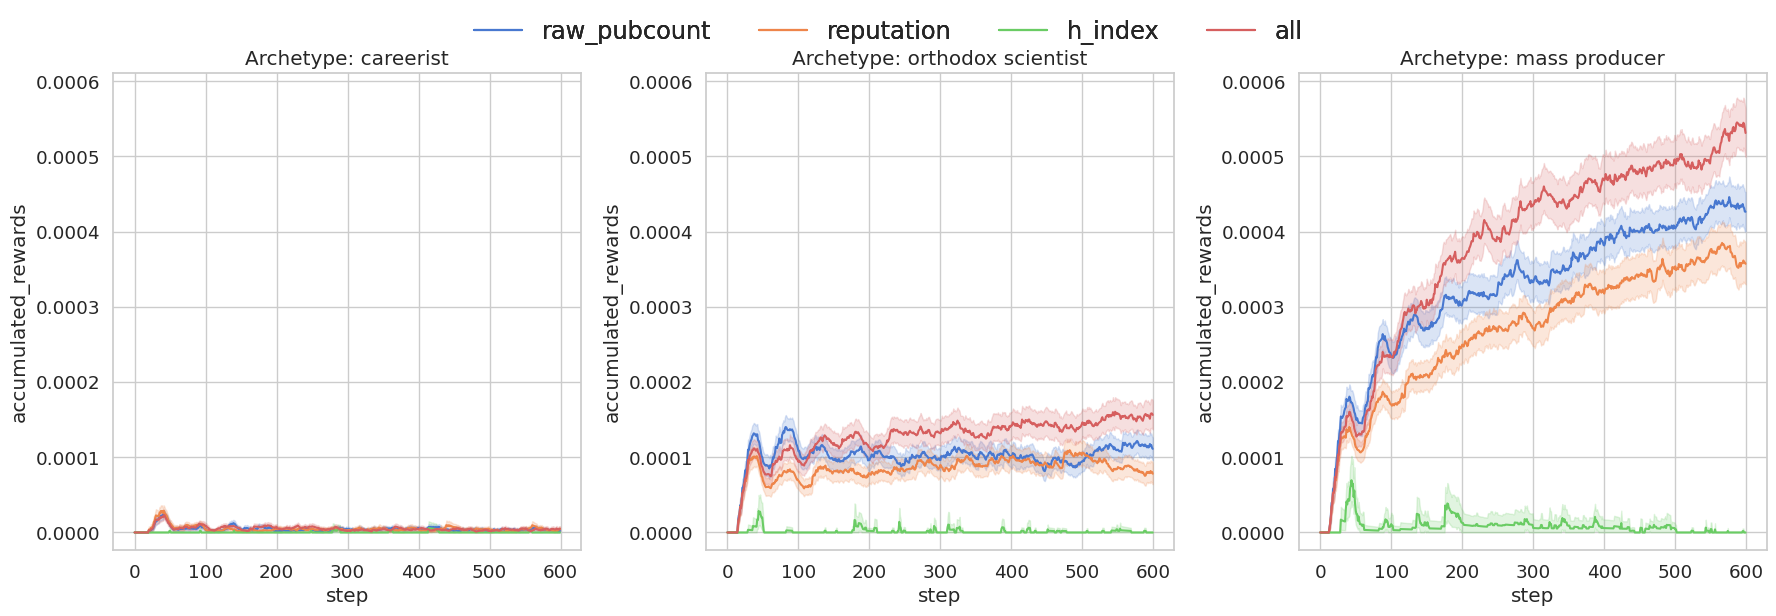

In [51]:

variants = ["raw_pubcount", "reputation", "h_index", "all"]
archetypes = ["careerist", "orthodox_scientist", "mass_producer"]
# ==========================================
# 2. STATISTICAL ANALYSIS
# ==========================================

# 1. Identify unique time steps
time_steps = list(range(600))
pairs = list(combinations(variants, 2))
pair_colors = ['#e41a1c', '#377eb8', '#4daf4a', "#fbe70f"] # Red, Blue, Green for the 3 pairs
# Create a figure with 3 subplots (one for each archetype)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)


# ==========================================
# 2. MAIN LOOP (Stats + Plotting)
# ==========================================

for idx, arch in enumerate(archetypes):
    ax = axes[idx] # Select the current subplot
    print(f"Processing Archetype: {arch}...")

    # --- A. PREPARE DATA FOR PLOTTING ---
    # Combine the 3 variant dataframes for this specific archetype into one
    # This makes plotting with Seaborn much easier
    plot_data = []
    for v in variants:
        #normalize
        max_reward = dfs[v]["accumulated_rewards"].max()

        df_subset = dfs[v][dfs[v]['archetype'] == arch].copy()
        df_subset['variant'] = v # Label the variant
        if max_reward>0:
            df_subset["accumulated_rewards"] /= max_reward
            df_subset["accumulated_rewards"] /= (dfs[v]["age"]+1)
        
        
        plot_data.append(df_subset)
    
    combined_df = pd.concat(plot_data)    

    # --- B. PLOT PERFORMANCE CURVES ---
    sns.lineplot(
        data=combined_df, 
        x='step', 
        y='accumulated_rewards', 
        hue='variant', 
        ax=ax,
        errorbar=('ci'),
        n_boot=5000,
        seed=10,
        # errorbar=('se')
    )
    
    # --- C. STATISTICAL TESTS ---
    pairwise_results = {}
    
    for pair_idx, (distr1, distr2) in enumerate(pairs):
        raw_p_values = []
        
        # We assume time_steps are aligned. 
        # Optimized data retrieval:
        df1 = combined_df[(combined_df['archetype'] == arch) & (combined_df["variant"] == distr1)]
        df2 = combined_df[(combined_df['archetype'] == arch) & (combined_df["variant"] == distr2)]

        for t in time_steps:
            # Fast filtering
            d1 = df1[df1['step'] == t]['accumulated_rewards'].values
            d2 = df2[df2['step'] == t]['accumulated_rewards'].values
            
            # Check variance
            if len(d1) > 1 and len(d2) > 1 and not (np.all(d1 == d1[0]) and np.all(d2 == d2[0]) and d1[0] == d2[0]):
                try:
                    stat, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
                    raw_p_values.append(p)
                except ValueError:
                    raw_p_values.append(1.0)
            else:
                raw_p_values.append(1.0)

        # FDR Correction
        reject, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')
        
        # Store results and index for coloring
        pairwise_results[f"{distr1} vs {distr2}"] = (reject, pair_idx)
    for pairing in pairwise_results:
        proportion = np.sum(pairwise_results[pairing][0]) / len(pairwise_results[pairing][0])
        print(f"{pairing}: {proportion:2f}")

    # --- D. PLOT SIGNIFICANCE BARS ---
    # Calculate where to put the bars (above the highest data point)
    # y_min, y_max = ax.get_ylim()
    # y_range = y_max - y_min
    # current_height = y_max + (y_range * 0.02) # Start slightly above plot
    # step_height = y_range * 0.05 # Distance between bars
    
    # # Loop through results and plot markers
    # for label, (is_sig, color_idx) in pairwise_results.items():
    #     sig_steps = np.array(time_steps)[is_sig]
        
    #     if len(sig_steps) > 0:
    #         # Plot horizontal line segments or markers
    #         ax.scatter(
    #             sig_steps, 
    #             [current_height] * len(sig_steps), 
    #             marker='|', 
    #             s=20, 
    #             color=pair_colors[color_idx], 
    #             label=label if idx == 0 else "" # Only add to legend on first plot
    #         )
    #     current_height += step_height

    # Final Styling
    ax.set_title(f"Archetype: {arch.replace('_', ' ')}")
    ax.set_ylim(y_min, current_height + step_height) # Expand limit to fit bars
    
    # Remove per-subplot legends entirely
    for ax in axes:
        leg = ax.get_legend()
        if leg:
            leg.remove()

    # Collect handles and labels from the first axis
    handles, labels = axes[0].get_legend_handles_labels()

    # Create a single, centered legend across the top
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.05),   # position above the subplots
        ncol=len(labels),             # spread across full width
        fontsize='large',
        frameon=False
    )


plt.tight_layout()
plt.show()

Processing Archetype: careerist...
publication count vs reputation score False 0.40554727864736395
publication count vs h-index True 0.0036390006537086496
reputation score vs h-index True 0.0003841747920439116
Processing Archetype: orthodox_scientist...
publication count vs reputation score False 0.2865549469650931
publication count vs h-index True 1.471760440741095e-21
reputation score vs h-index True 1.2946540446681283e-16
Processing Archetype: mass_producer...
publication count vs reputation score False 0.7299606522805586
publication count vs h-index True 6.779617191295658e-74
reputation score vs h-index True 5.296545779854926e-72


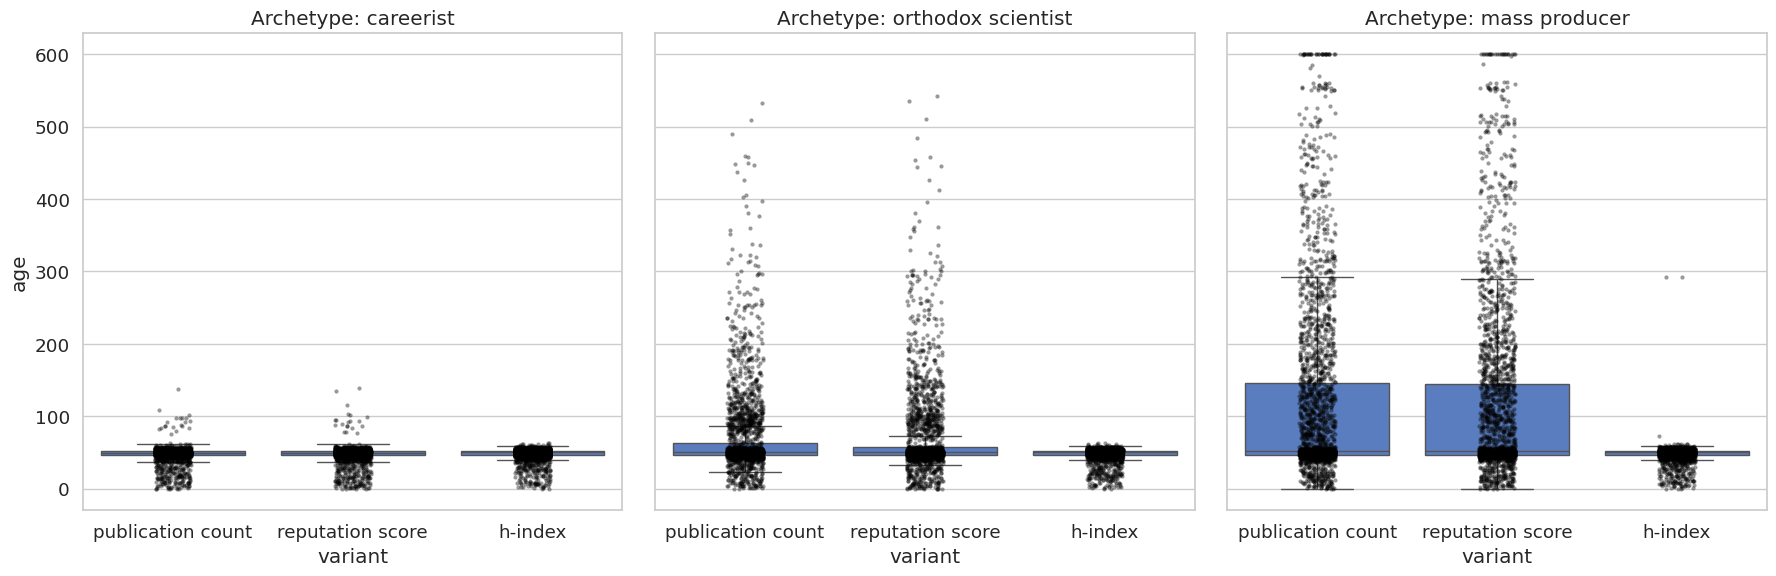

In [43]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
variants = ["raw_pubcount", "reputation", "h_index"]

variants = {"raw_pubcount": "publication count", "reputation": "reputation score", "h_index": "h-index"}
archetypes = ["careerist", "orthodox_scientist", "mass_producer"]

pairs = list(combinations(variants, 2))
pair_colors = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, arch in enumerate(archetypes):
    ax = axes[idx]
    print(f"Processing Archetype: {arch}...")

    # =============================
    # A. BUILD MAX-AGE DATASET
    # =============================
    plot_rows = []

    for v in variants:
        df = dfs[v][dfs[v]["archetype"] == arch]

        # Compute max age per agent
        max_age = df.groupby("agent_id")["age"].max().reset_index()
        max_age["variant"] = variants[v]

        plot_rows.append(max_age)

    combined_df = pd.concat(plot_rows, ignore_index=True)

    # =============================
    # B. PLOT THE DISTRIBUTIONS
    # =============================
    sns.boxplot(
        data=combined_df,
        x="variant",
        y="age",
        ax=ax,
        showcaps=True,
        showfliers=False
    )

    sns.stripplot(
        data=combined_df,
        x="variant",
        y="age",
        ax=ax,
        color="black",
        size=3,
        alpha=0.4
    )

    # =============================
    # C. PAIRWISE STATISTICAL TESTS
    # =============================
    p_values = []
    labels = []
    pairwise_results = {}


    for pair_idx, (v1, v2) in enumerate(pairs):
        d1 = combined_df[combined_df["variant"] == variants[v1]]["age"].values
        d2 = combined_df[combined_df["variant"] == variants[v2]]["age"].values

        # Mann-Whitney U test
        stat, p = stats.mannwhitneyu(d1, d2, alternative="two-sided")

        p_values.append(p)
        labels.append(f"{variants[v1]} vs {variants[v2]}")

    # FDR correction
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    for l,r,p_val in zip(labels, reject, pvals_corrected):
        print(l, r, p_val)

    ax.set_title(f"Archetype: {arch.replace('_', ' ')}")

plt.tight_layout()
plt.show()


In [56]:
seed = 1
reward_type = "all"
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_projects.json", "r") as f:
    balanced_multiply_projects = json.load(f)
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_actions.jsonl", "r") as f:
    balanced_multiply_actions = []
    for line in f.readlines():
        balanced_multiply_actions.append(json.loads(line))
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_observations.jsonl", "r") as f:
    balanced_multiply_observations = []
    for line in f.readlines():
        balanced_multiply_observations.append(json.loads(line))

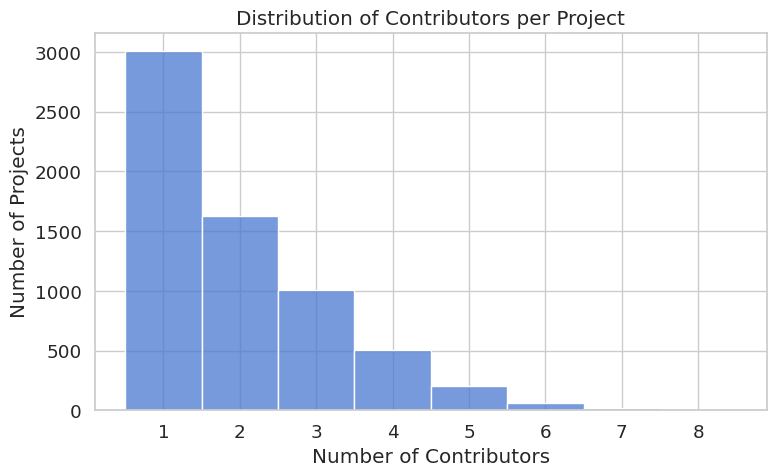

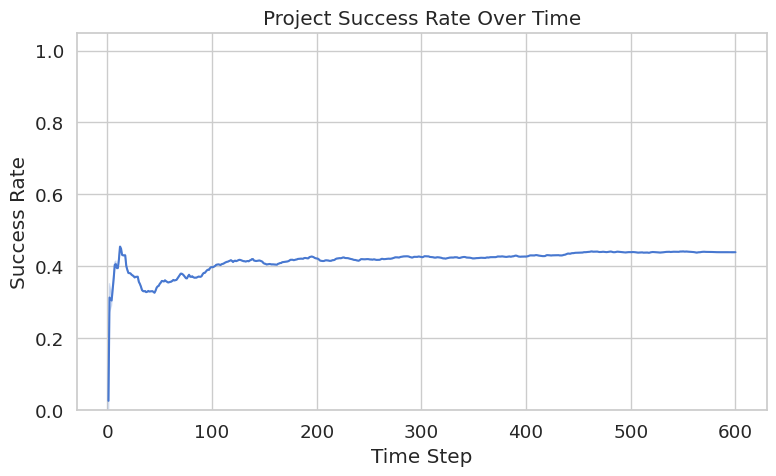

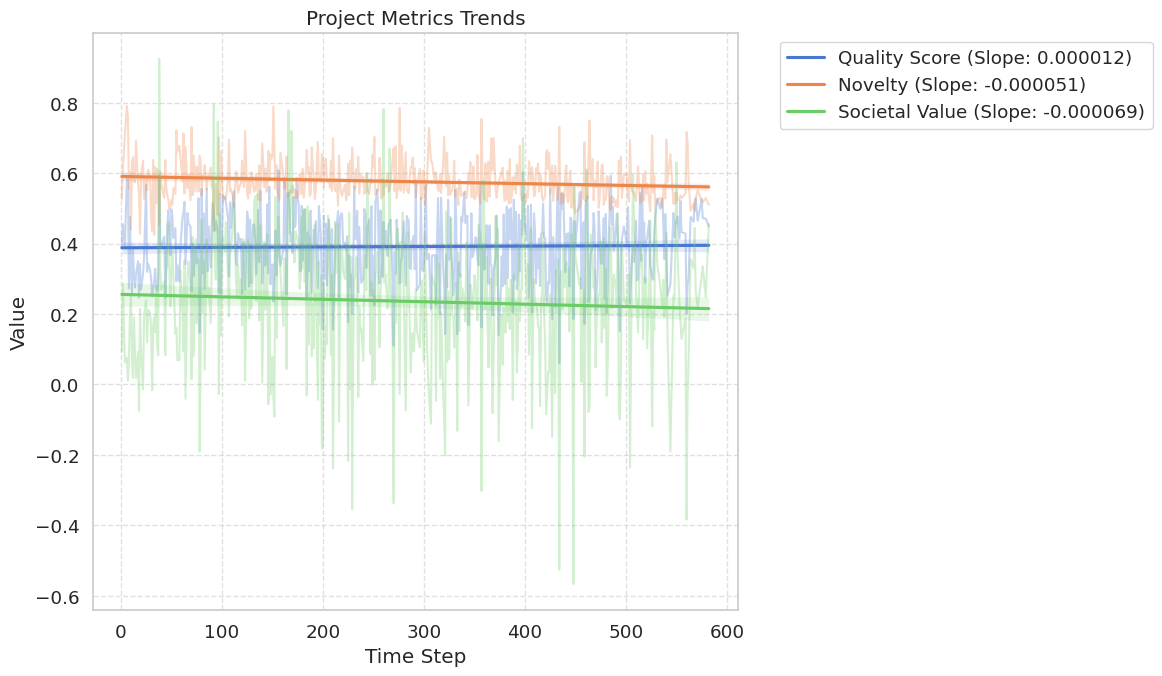

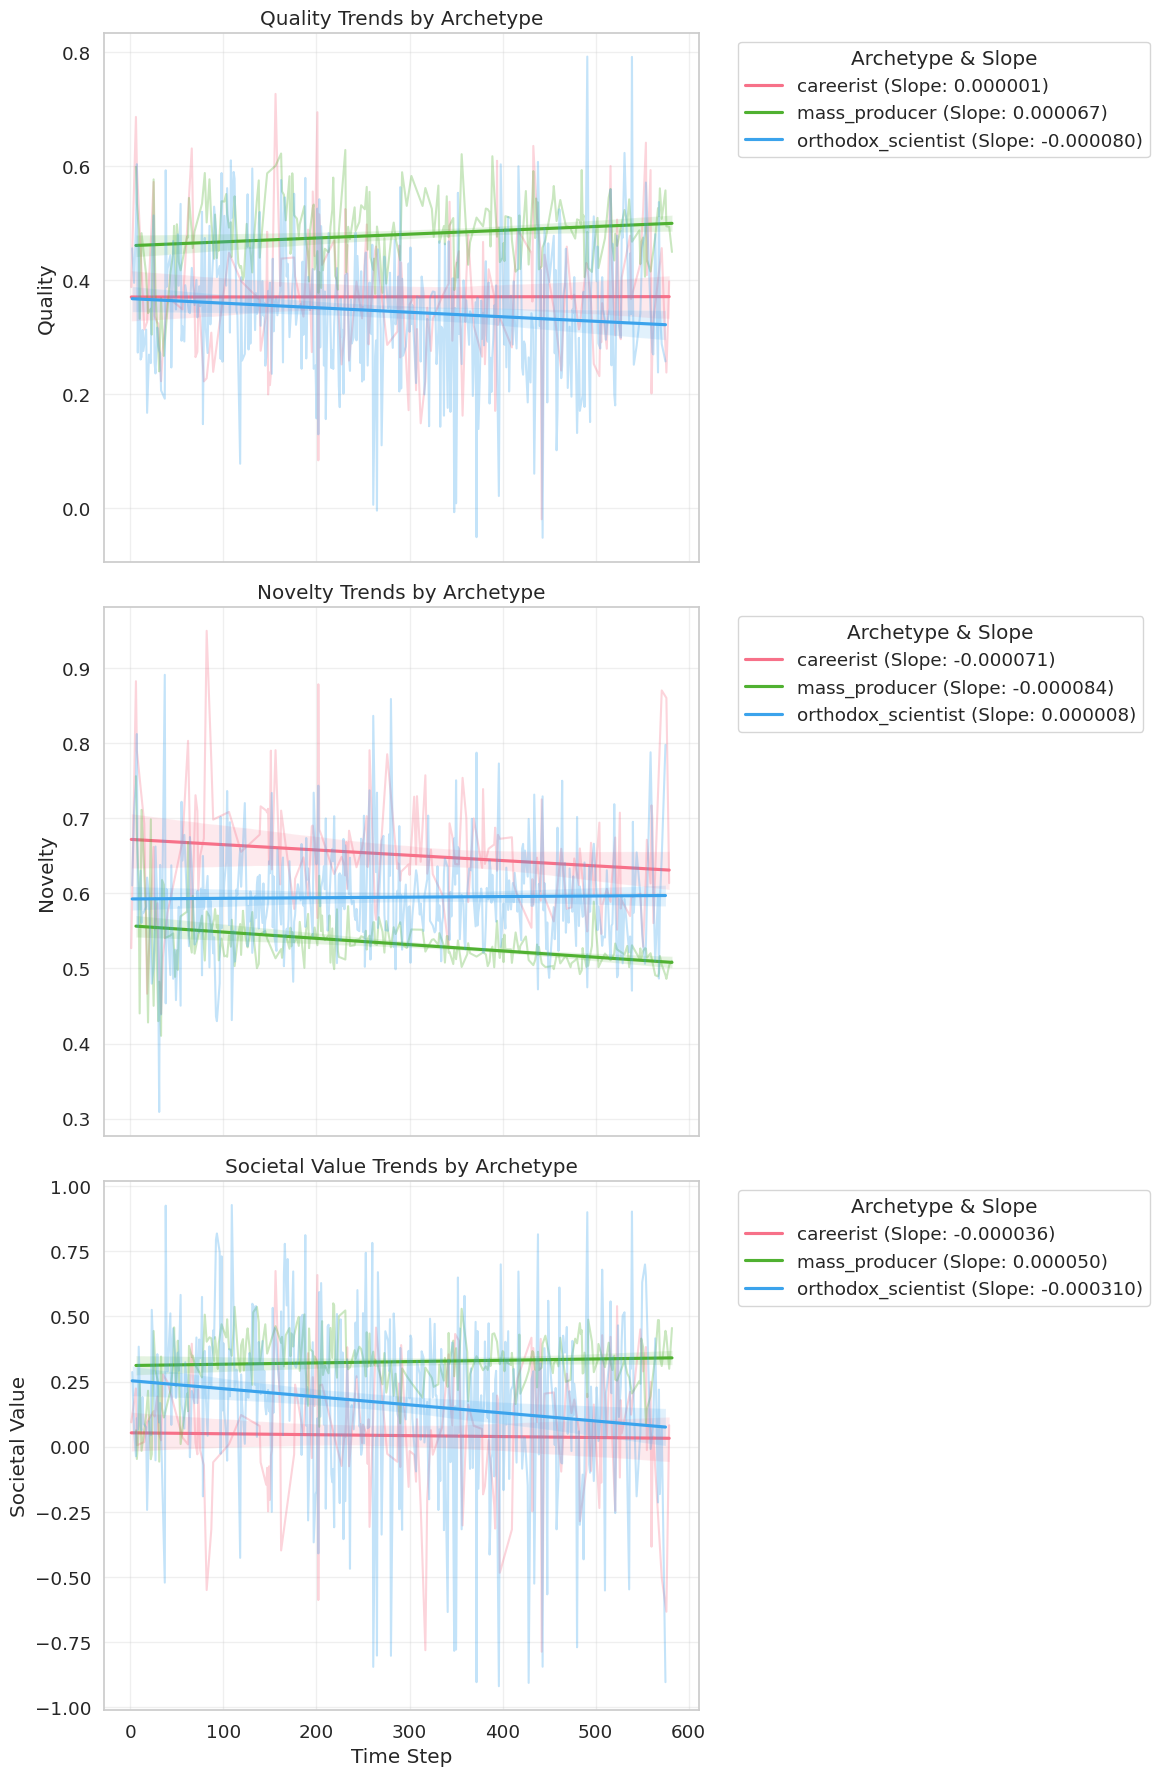

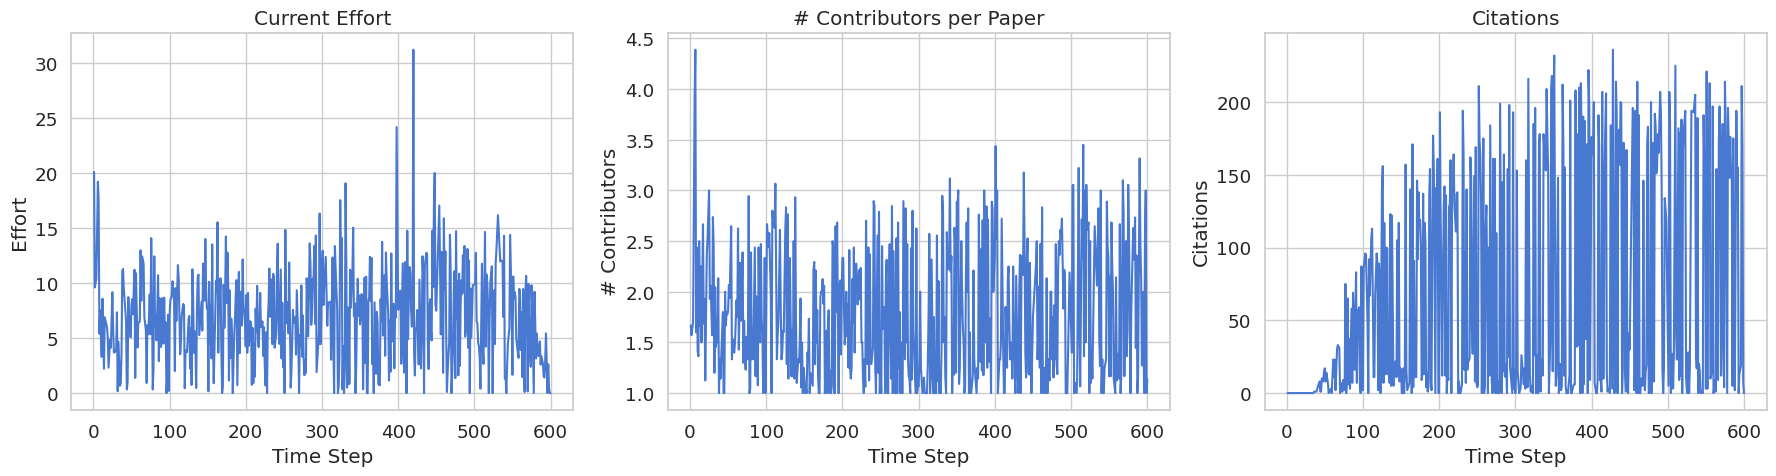

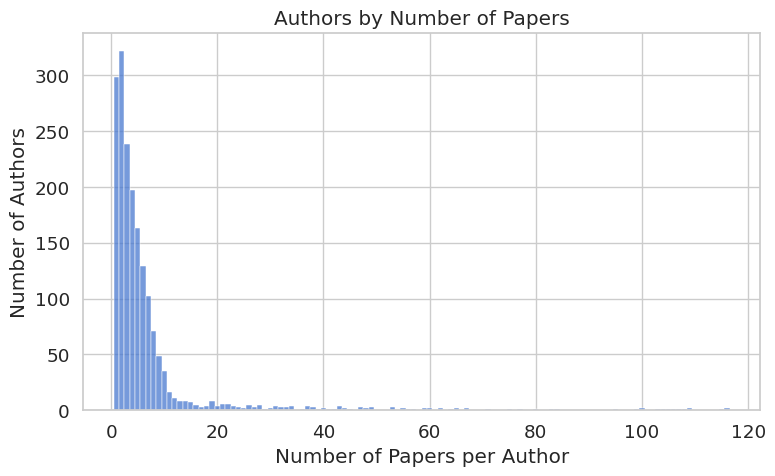

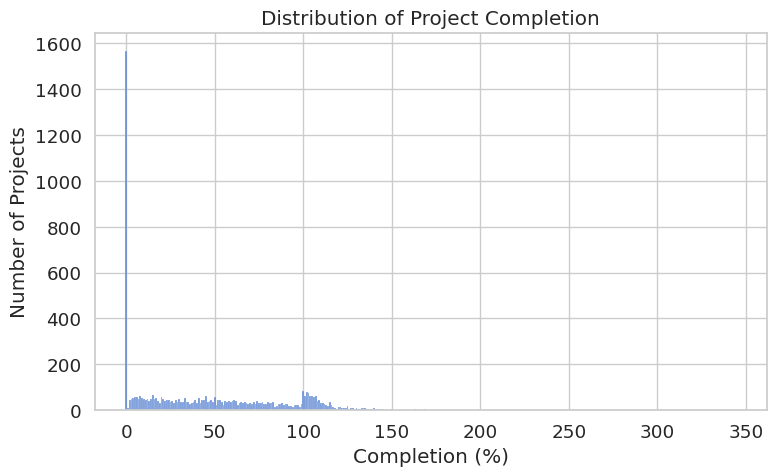

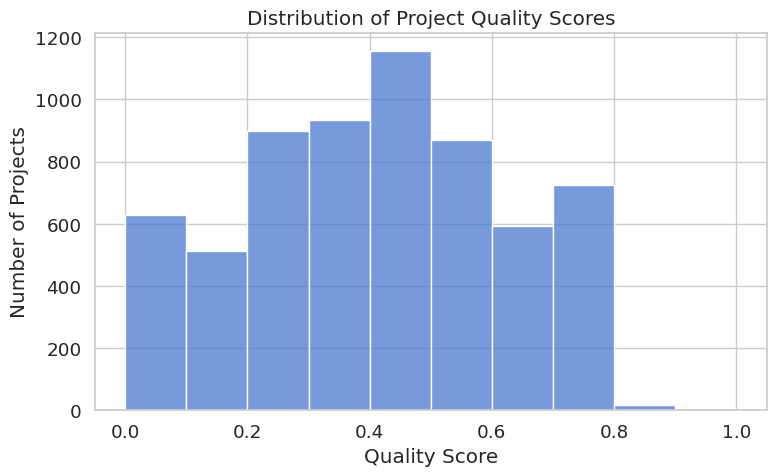

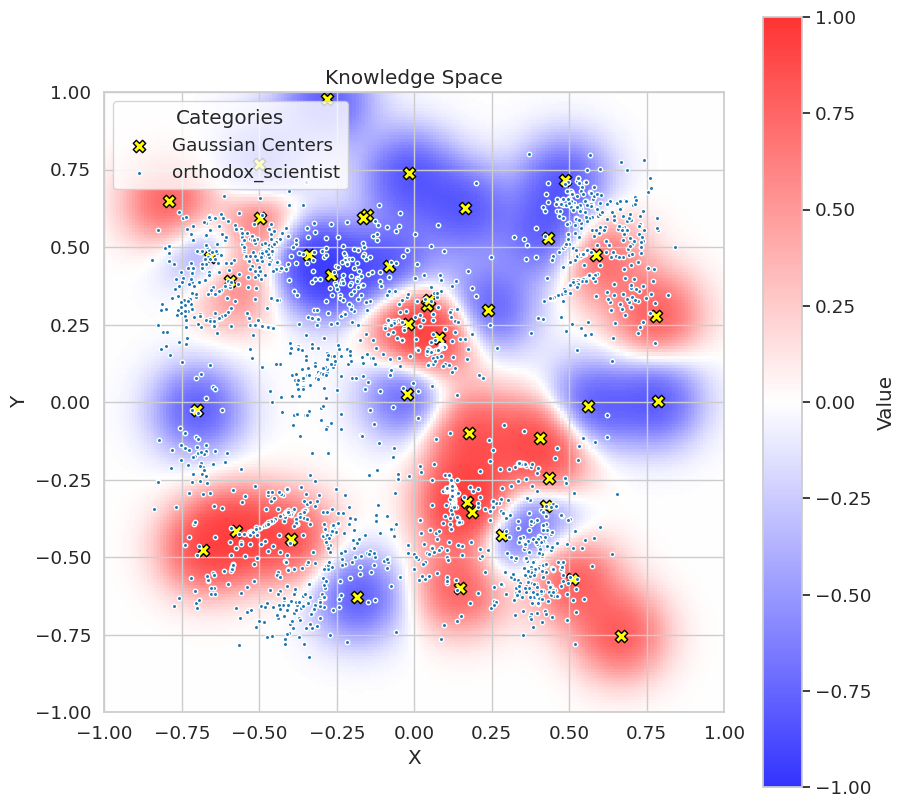

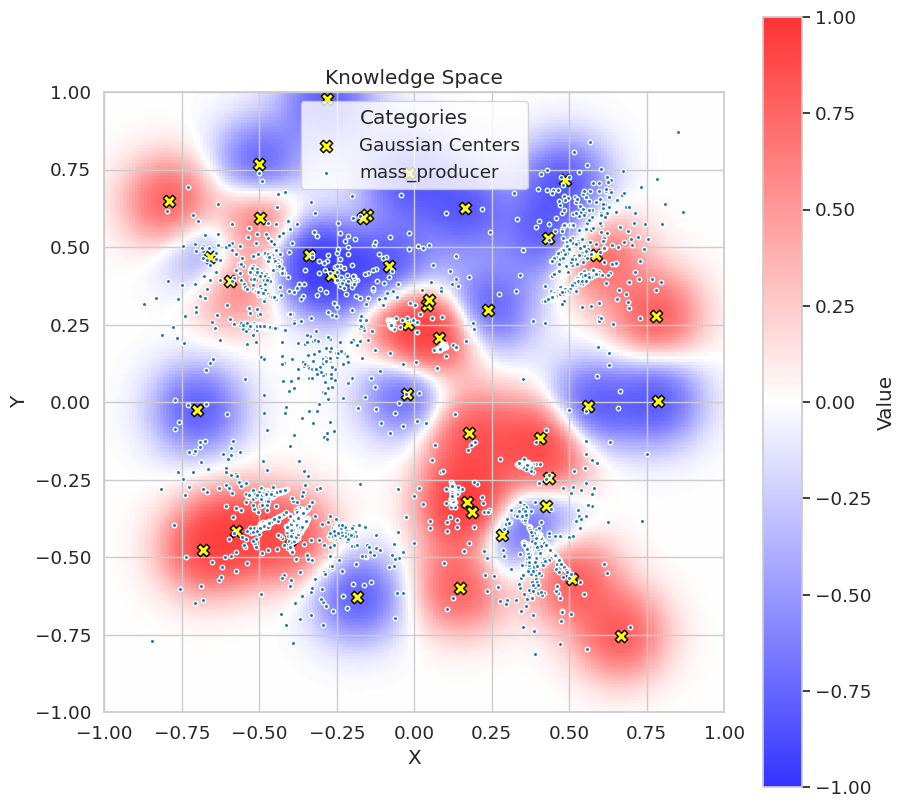

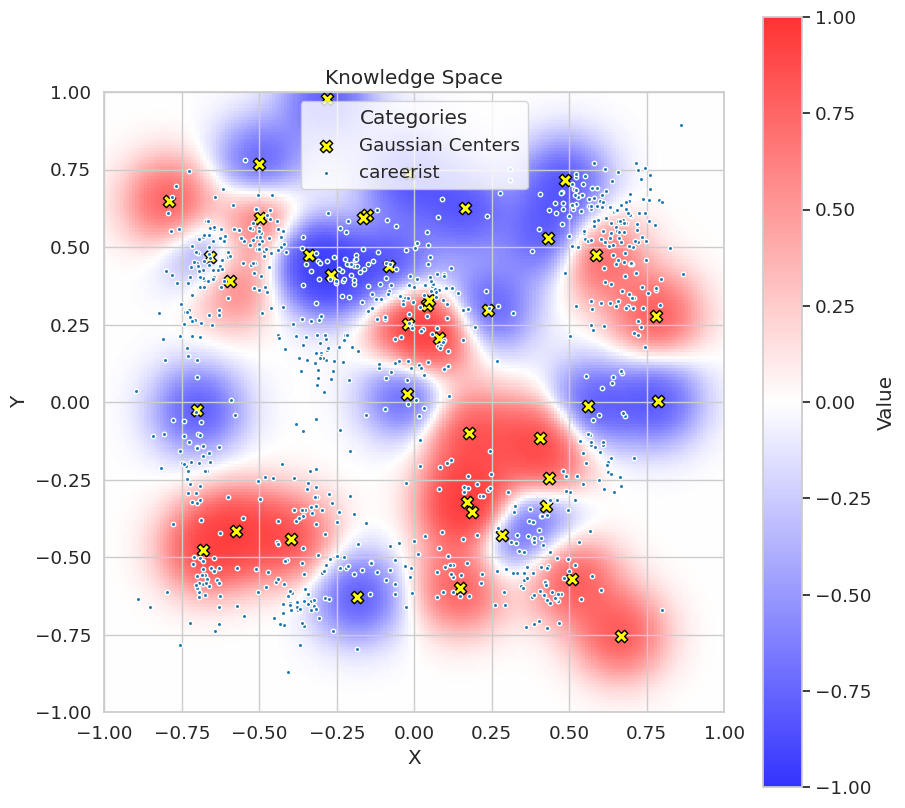

In [57]:
plot_histograms(balanced_multiply_projects, balanced_multiply_actions, f"log/balanced_{reward_type}_multiply_seed{seed}_area.pickle")

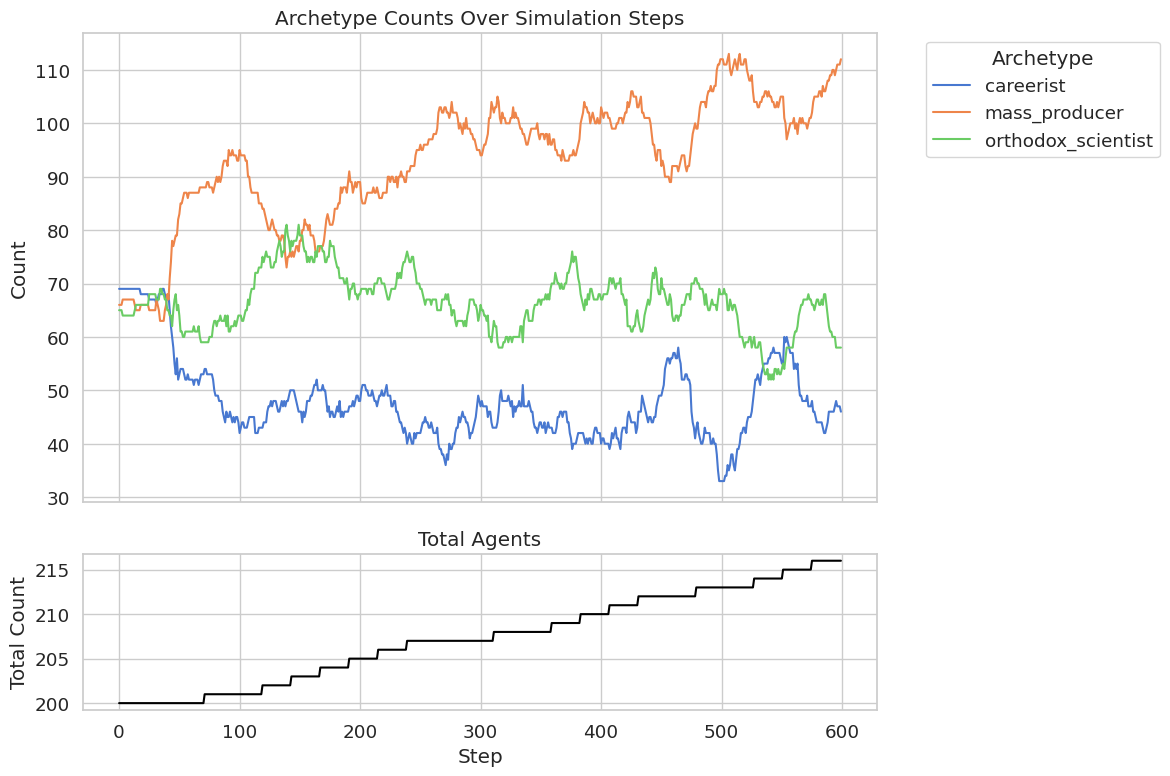

In [58]:
visualize_policy_population(balanced_multiply_actions)

<Figure size 640x480 with 0 Axes>

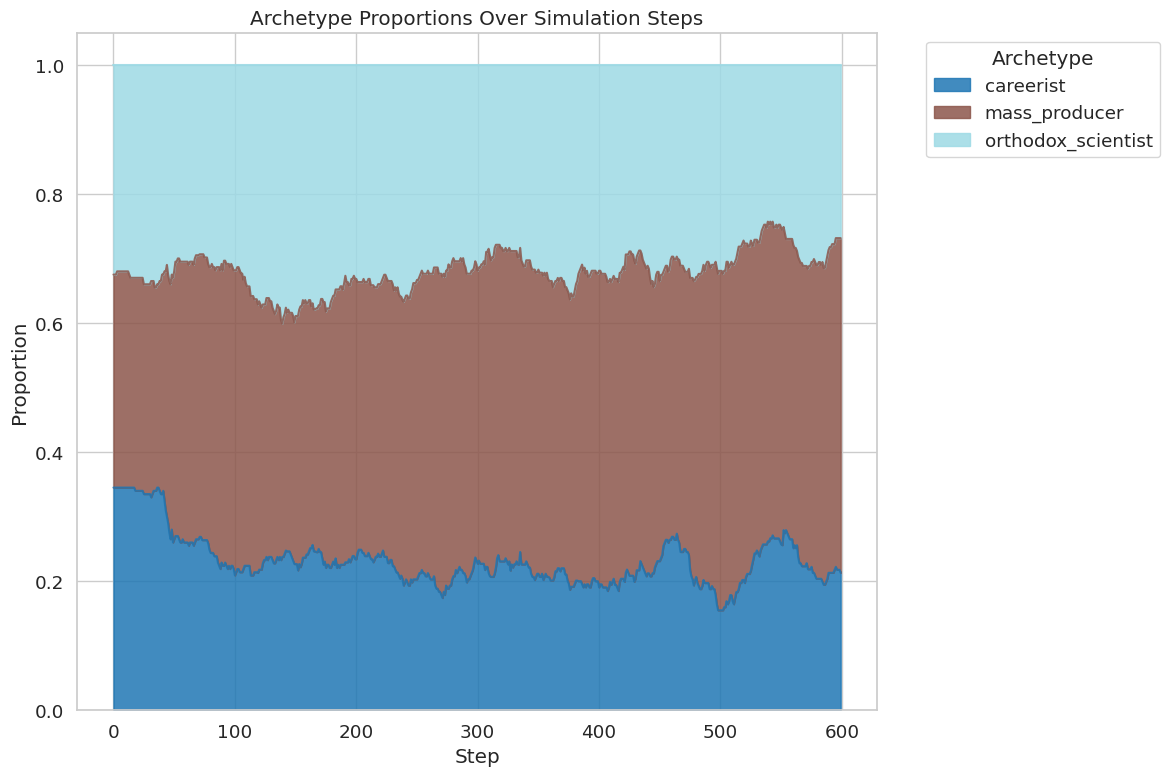

In [59]:
visualize_policy_population_proportion(balanced_multiply_actions)

In [60]:
seed = 1
reward_type = "reputation"
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_projects.json", "r") as f:
    balanced_multiply_projects = json.load(f)
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_actions.jsonl", "r") as f:
    balanced_multiply_actions = []
    for line in f.readlines():
        balanced_multiply_actions.append(json.loads(line))
with open(f"log/balanced_{reward_type}_multiply_seed{seed}_observations.jsonl", "r") as f:
    balanced_multiply_observations = []
    for line in f.readlines():
        balanced_multiply_observations.append(json.loads(line))

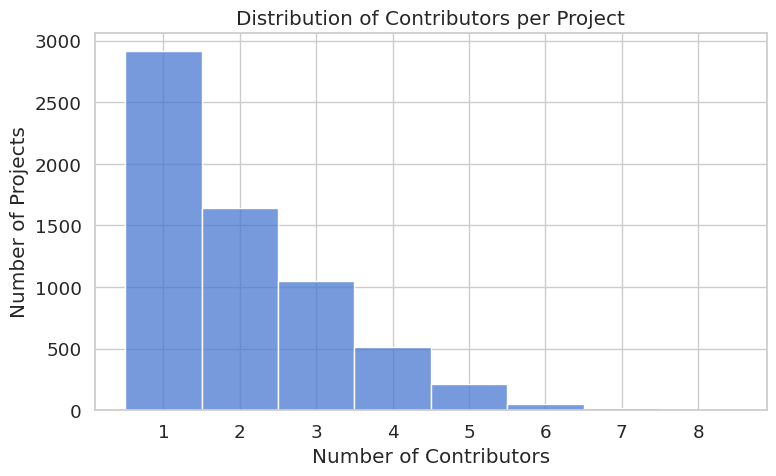

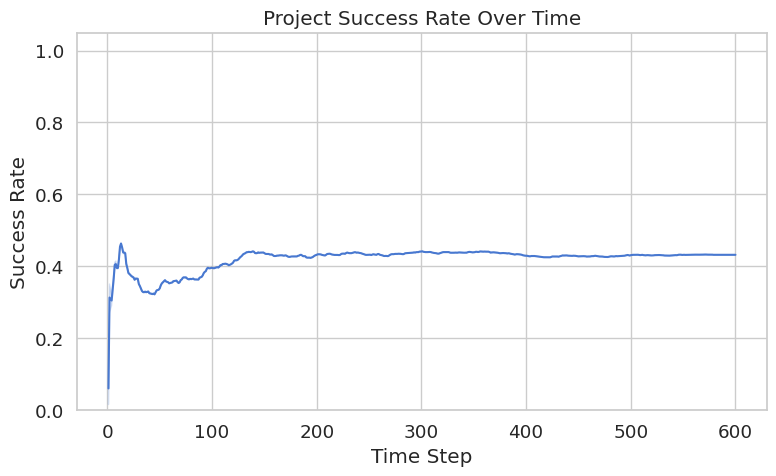

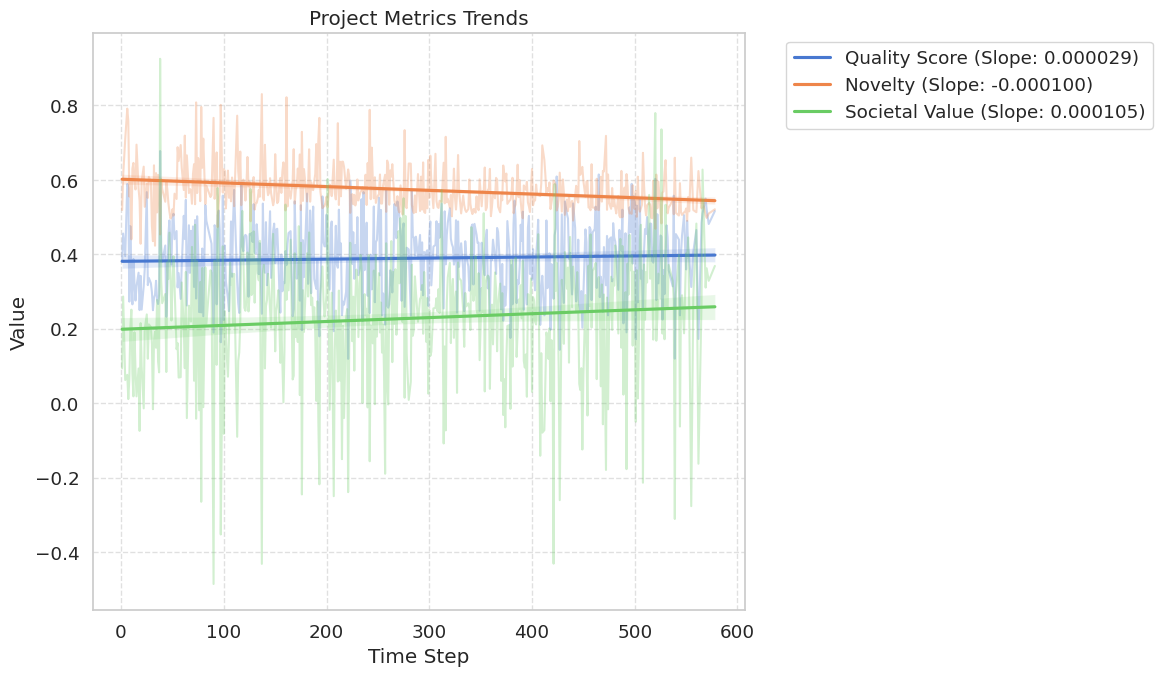

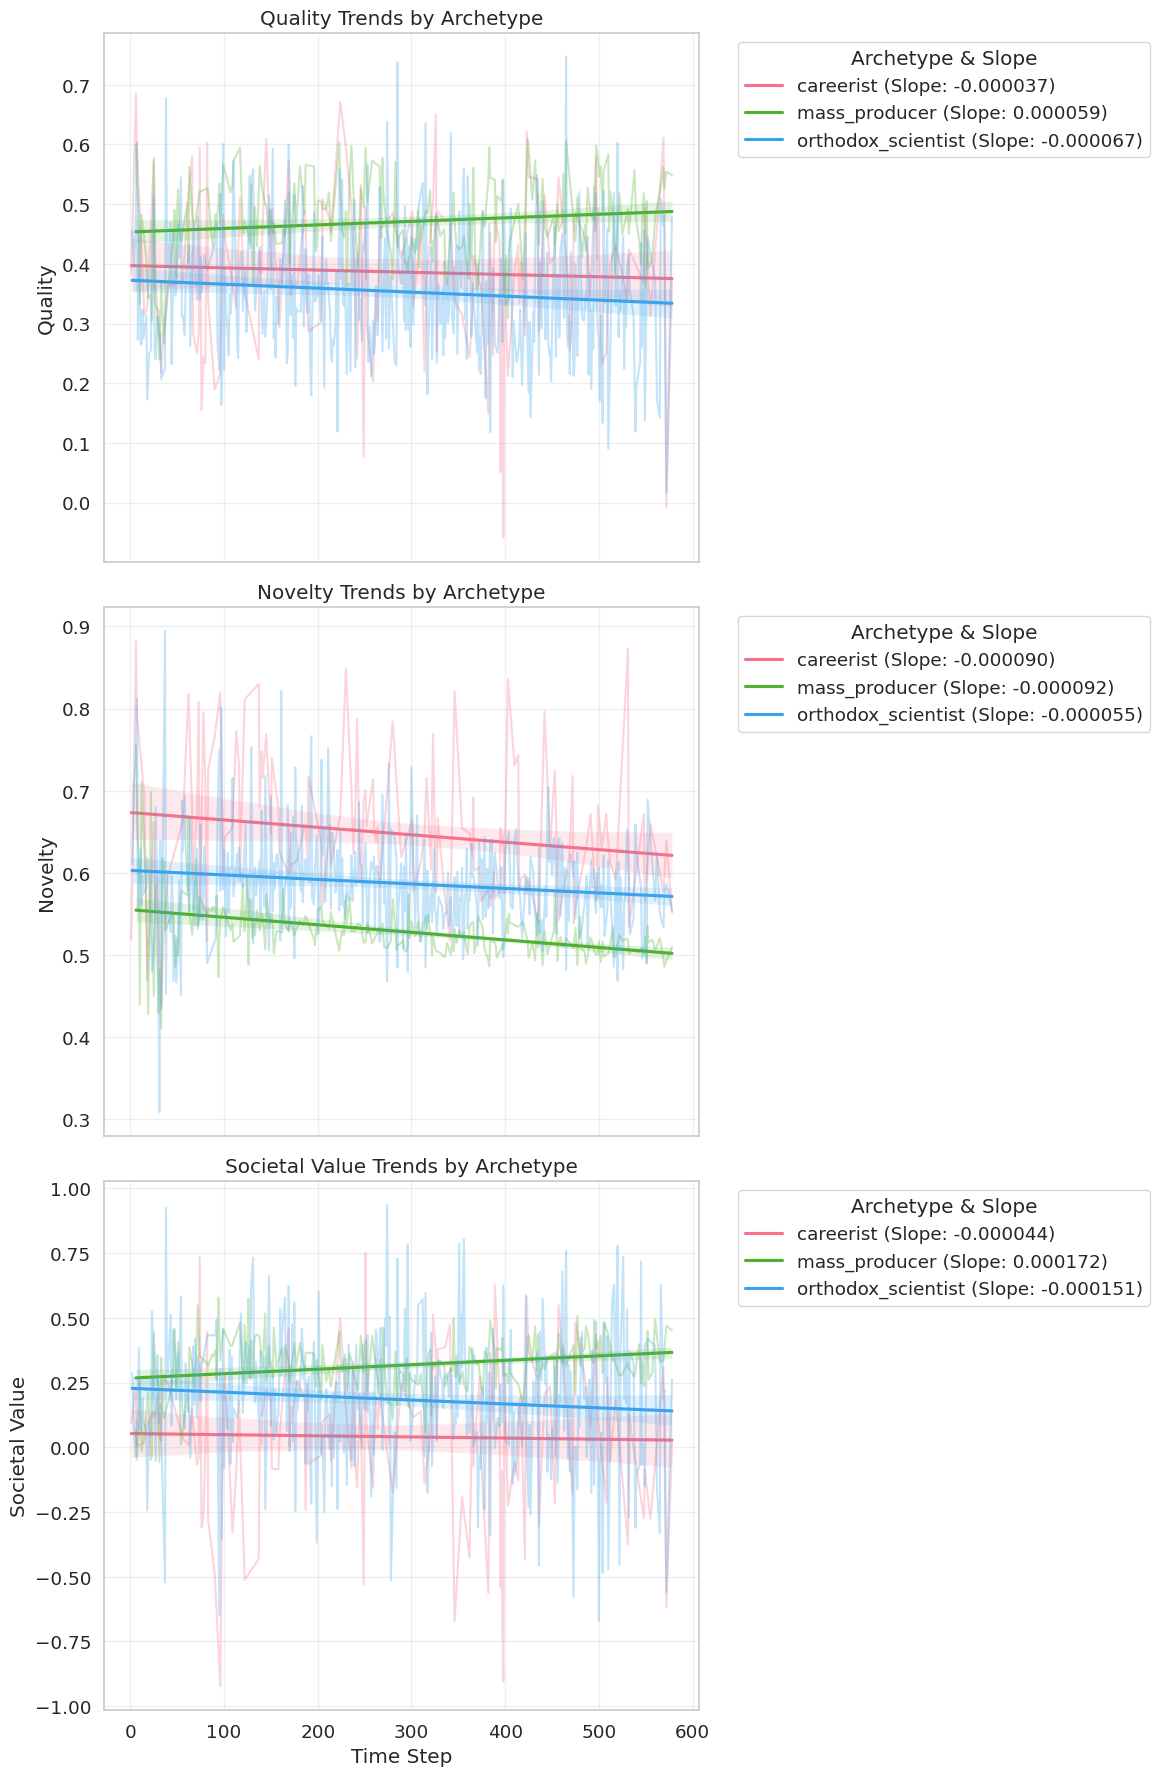

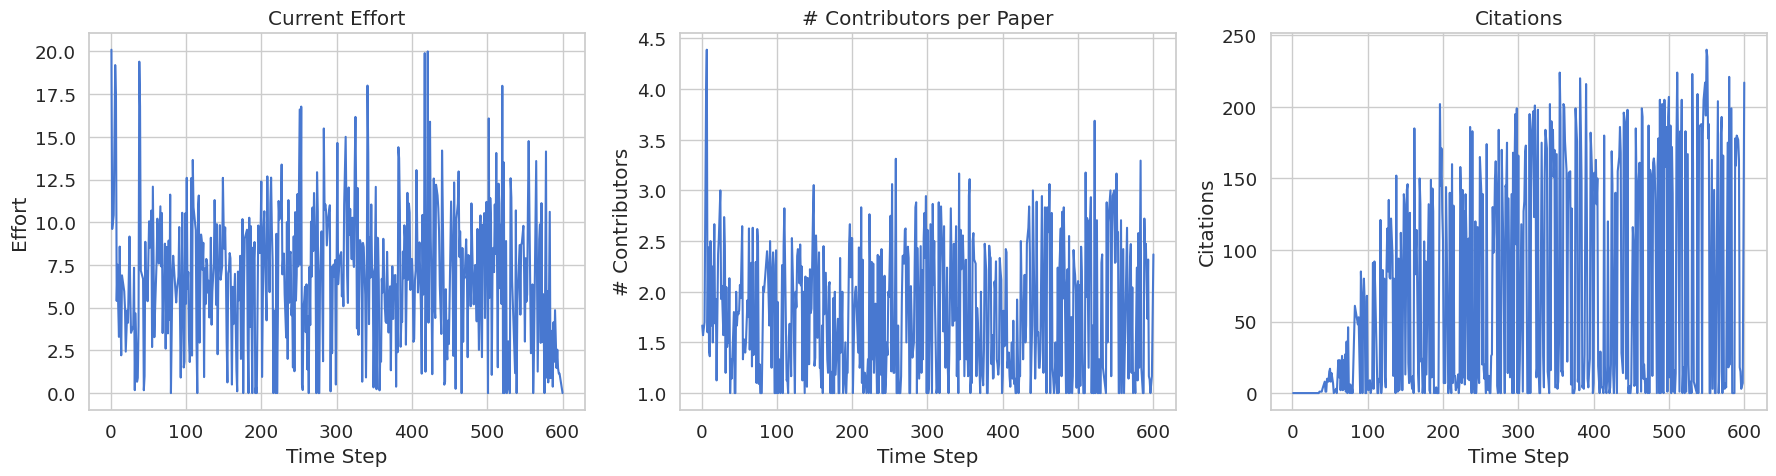

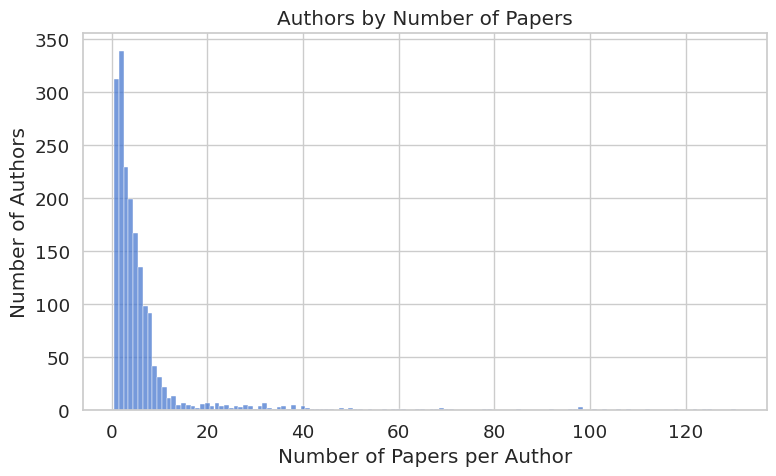

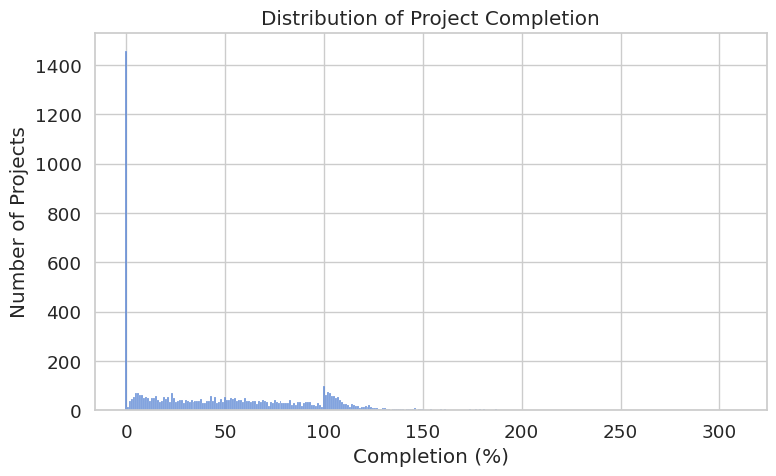

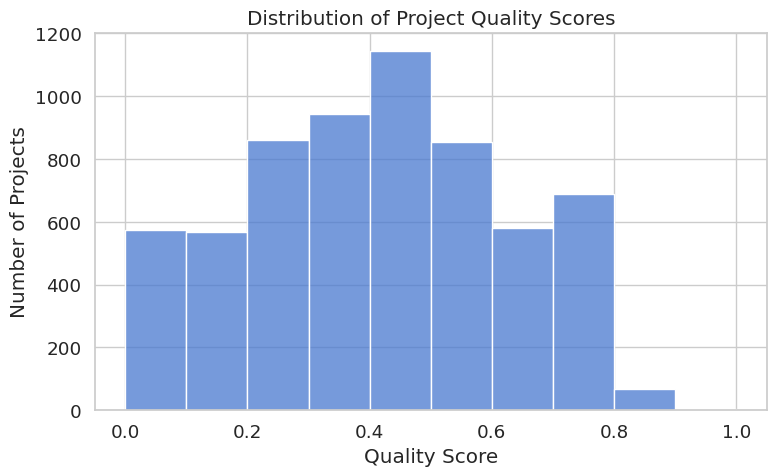

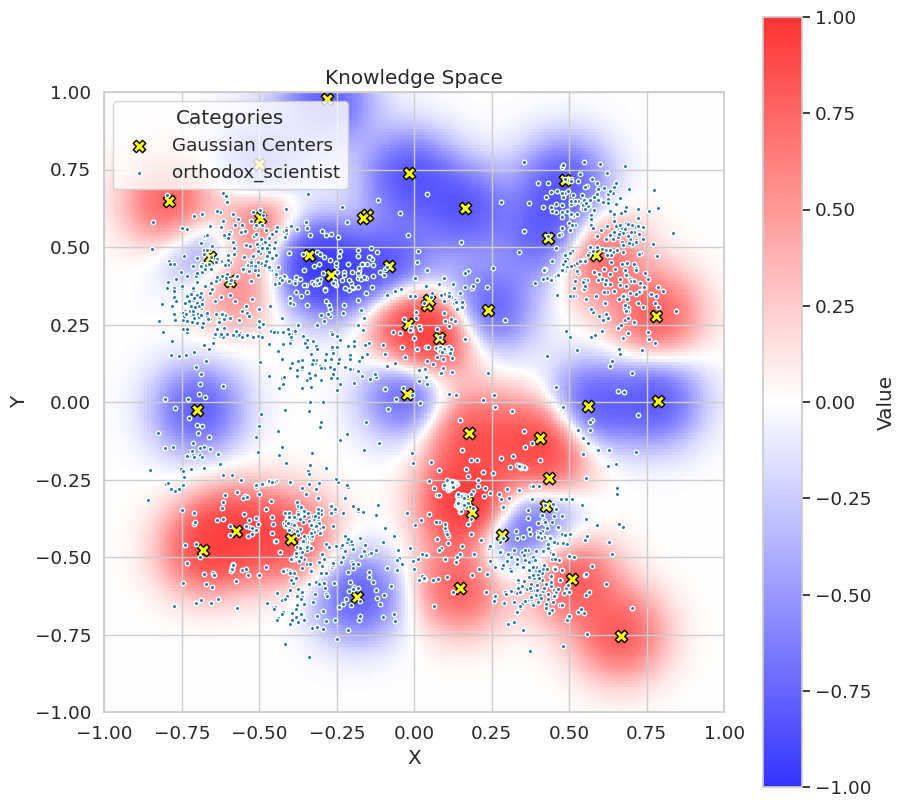

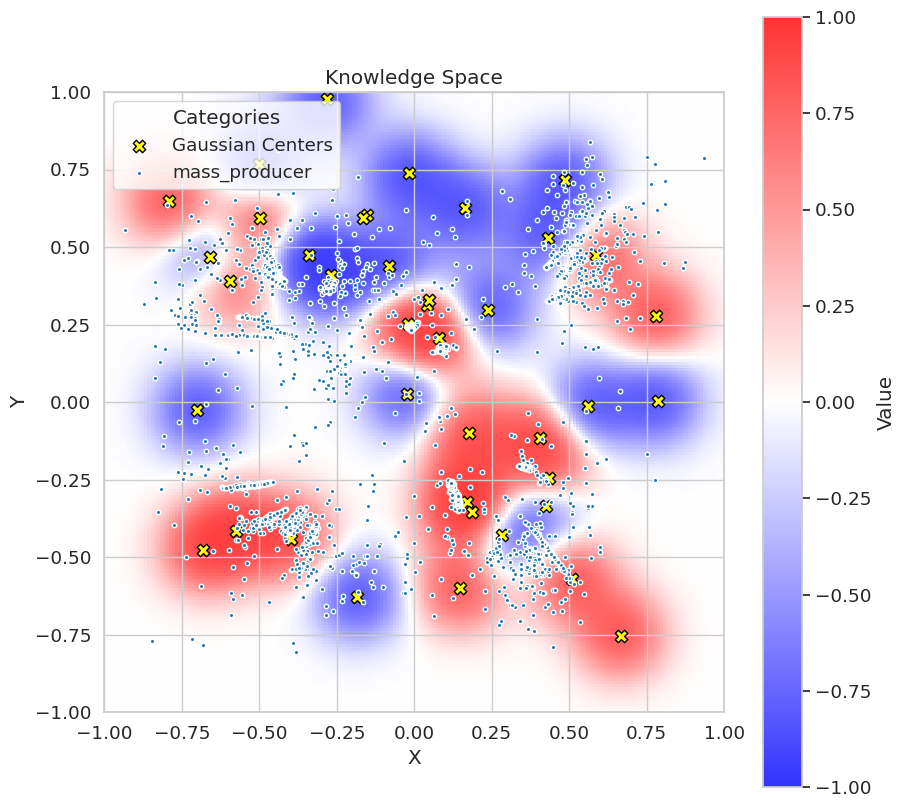

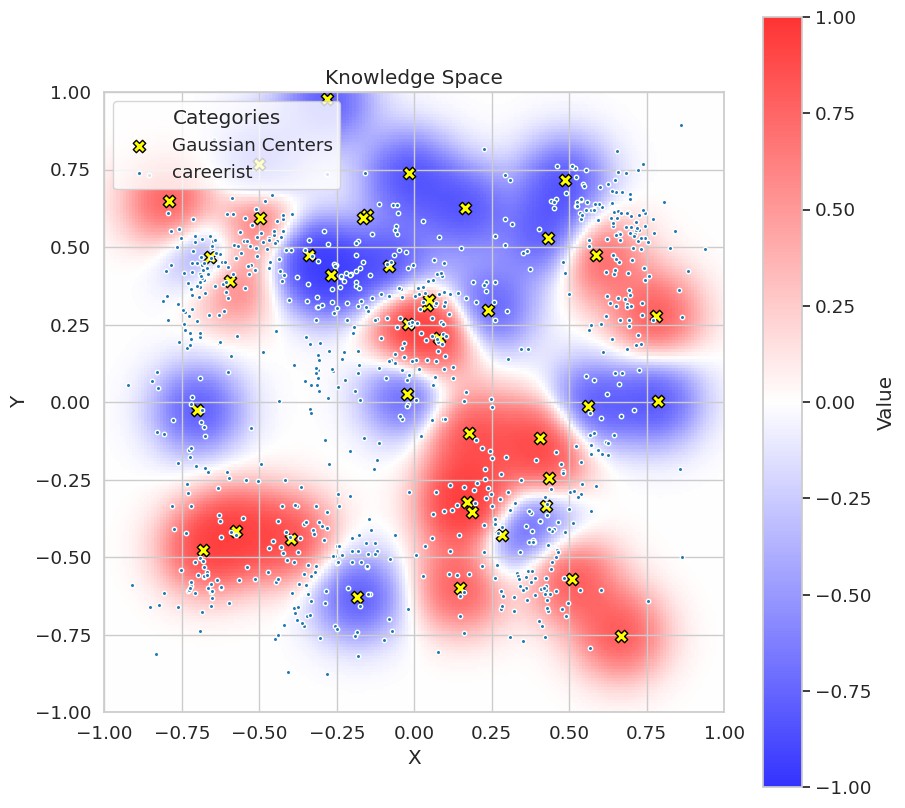

In [61]:
plot_histograms(balanced_multiply_projects, balanced_multiply_actions, f"log/balanced_{reward_type}_multiply_seed{seed}_area.pickle")

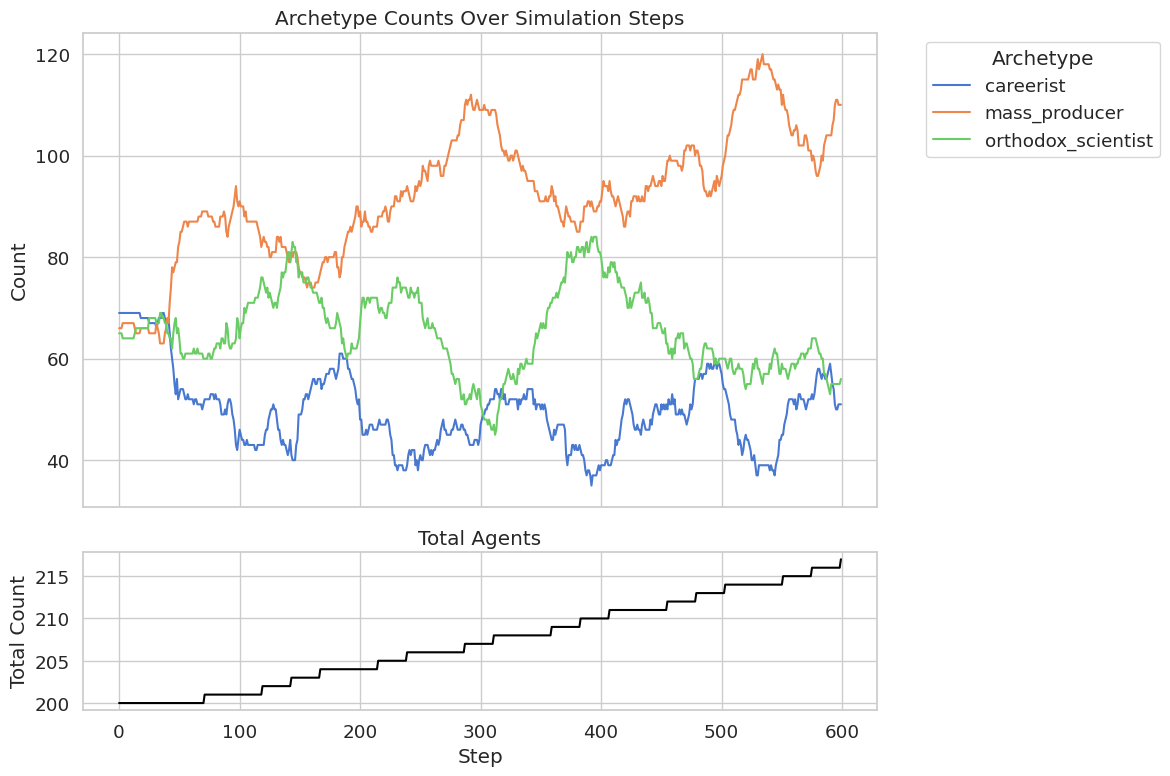

In [62]:
visualize_policy_population(balanced_multiply_actions)

In [63]:
seed = 42
reward_type = "all"
with open(f"log/balanced_adverse_{reward_type}_multiply_seed{seed}_projects.json", "r") as f:
    balanced_multiply_projects = json.load(f)
with open(f"log/balanced_adverse_{reward_type}_multiply_seed{seed}_actions.jsonl", "r") as f:
    balanced_multiply_actions = []
    for line in f.readlines():
        balanced_multiply_actions.append(json.loads(line))
with open(f"log/balanced_adverse_{reward_type}_multiply_seed{seed}_observations.jsonl", "r") as f:
    balanced_multiply_observations = []
    for line in f.readlines():
        balanced_multiply_observations.append(json.loads(line))

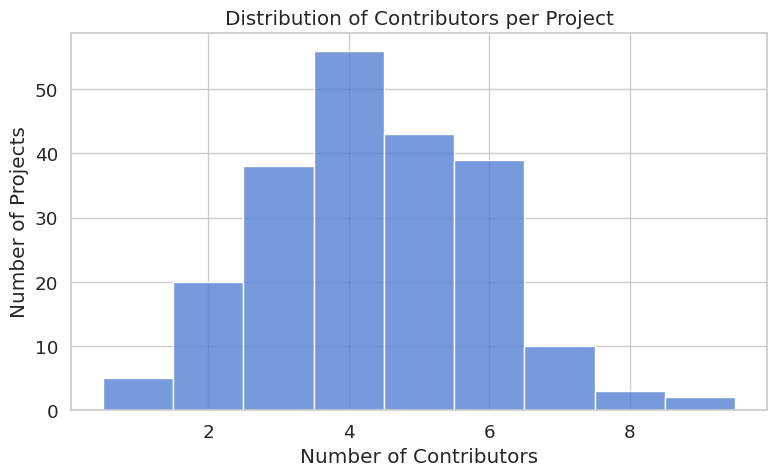

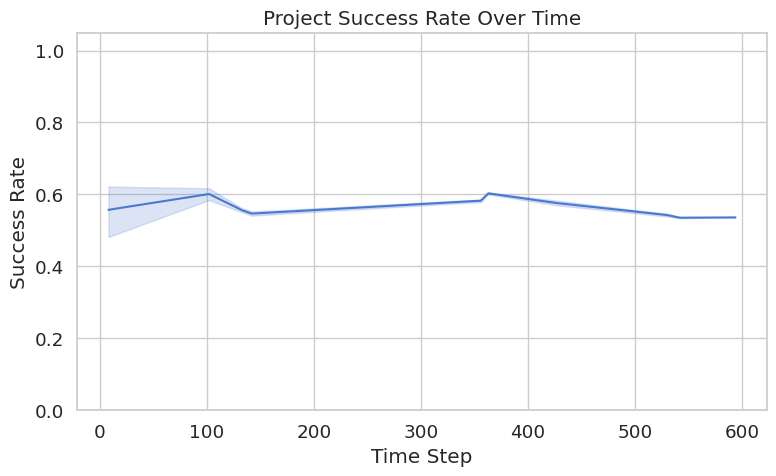

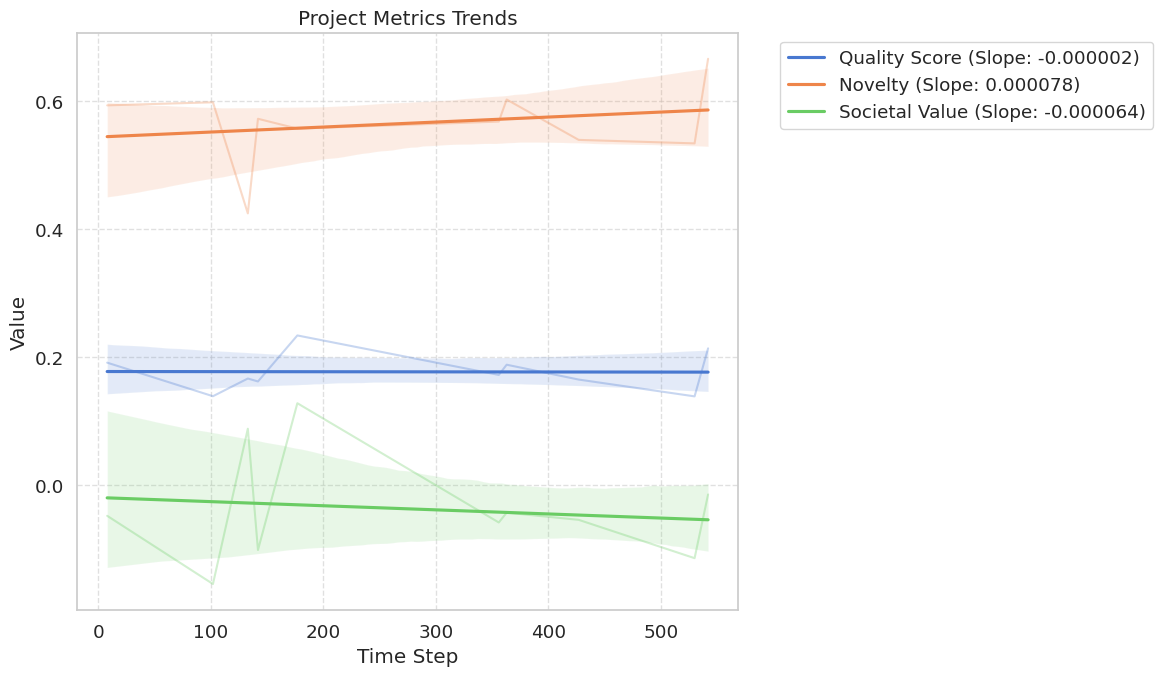

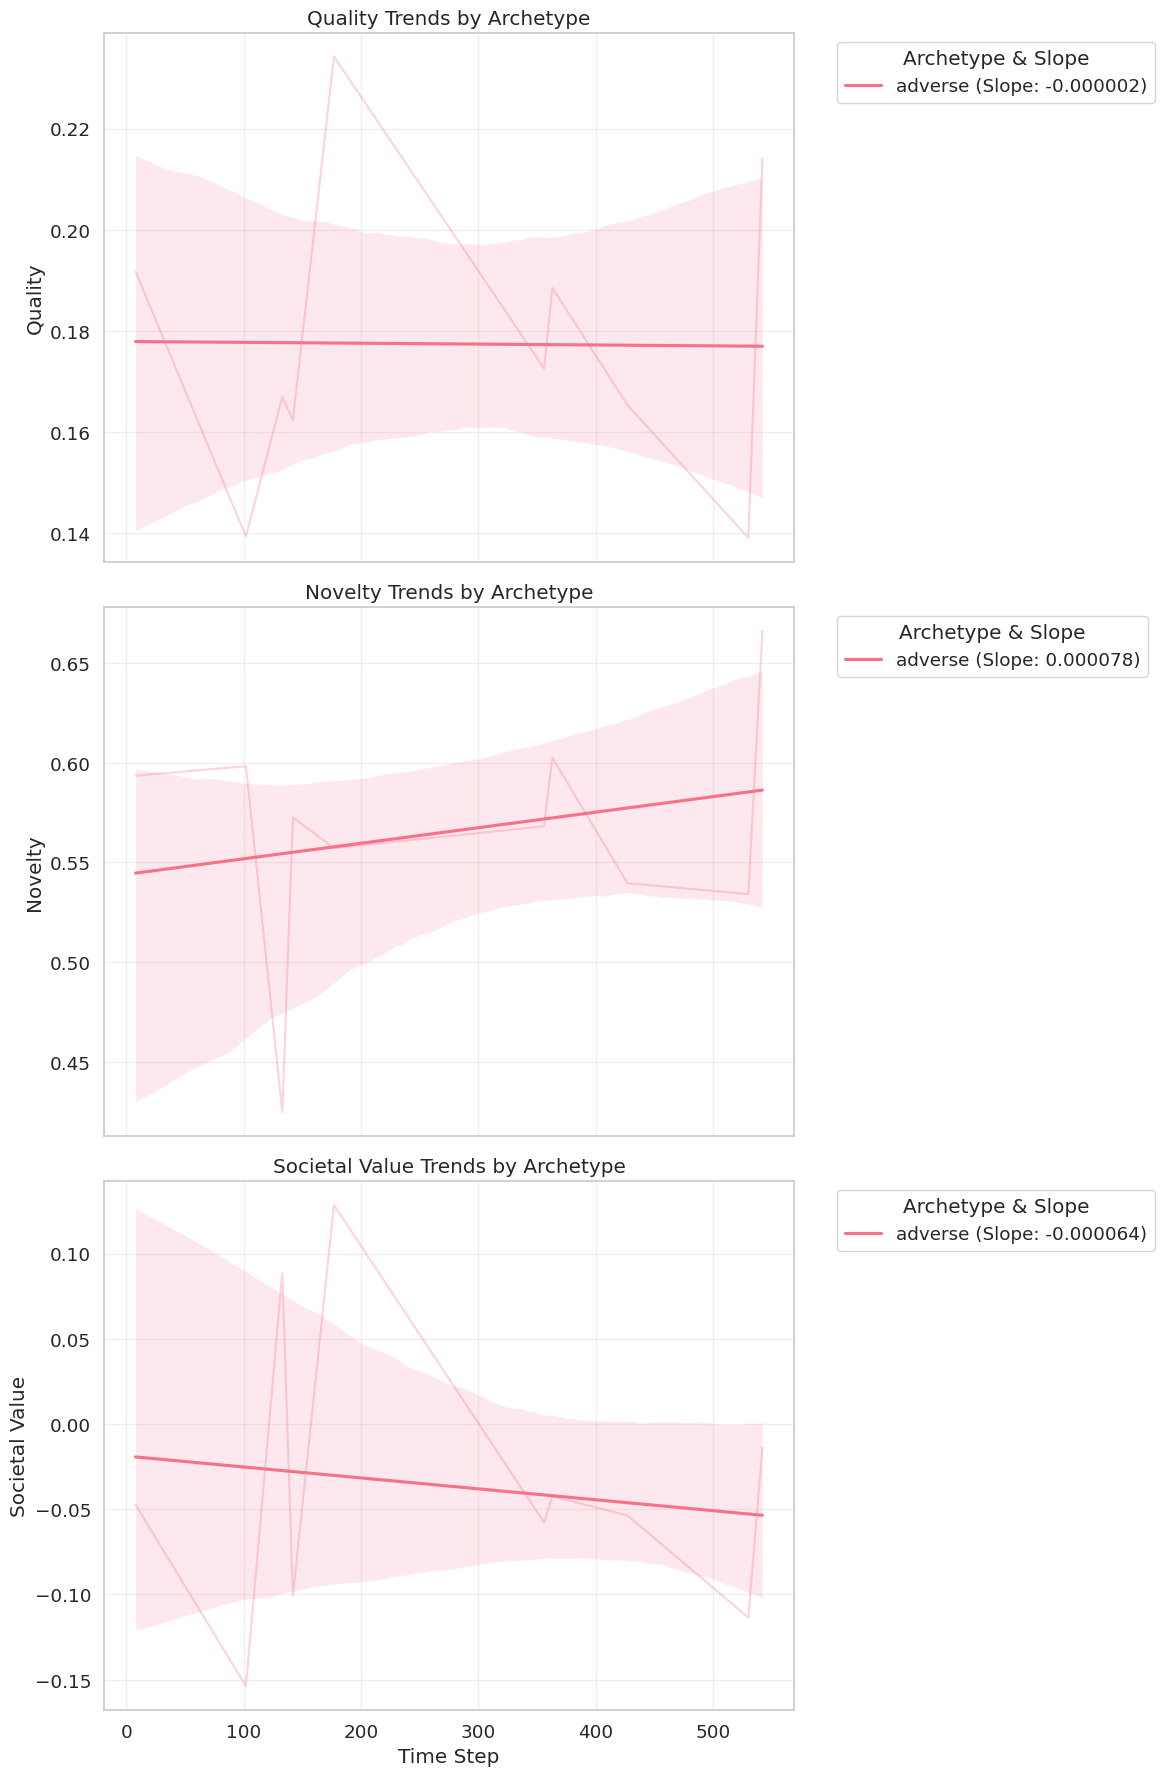

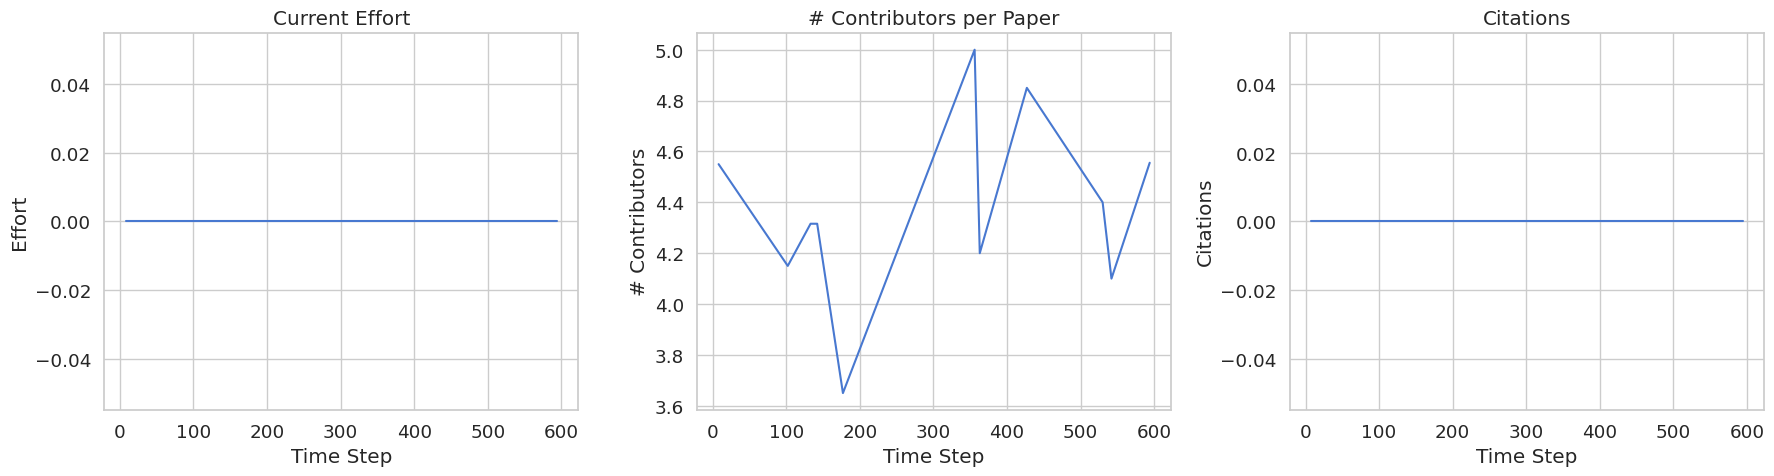

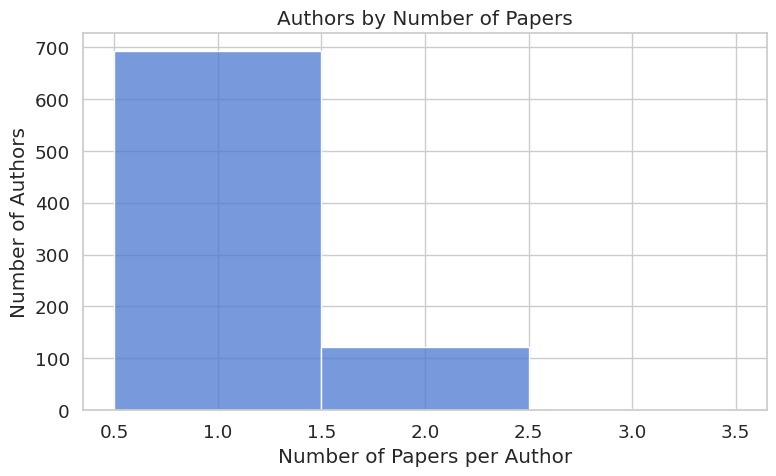

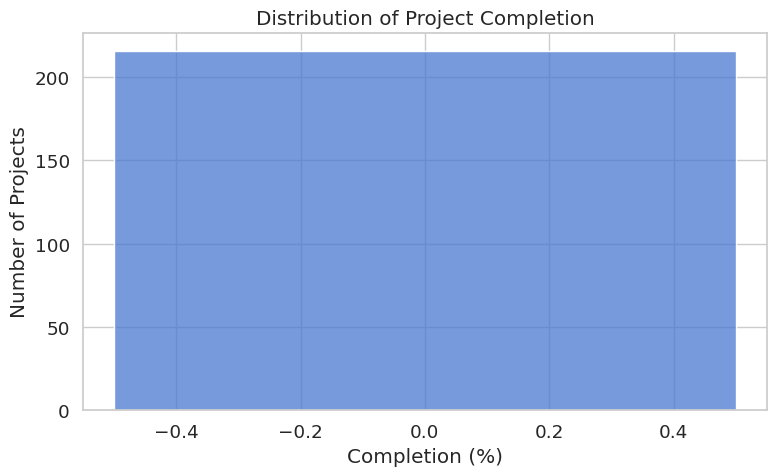

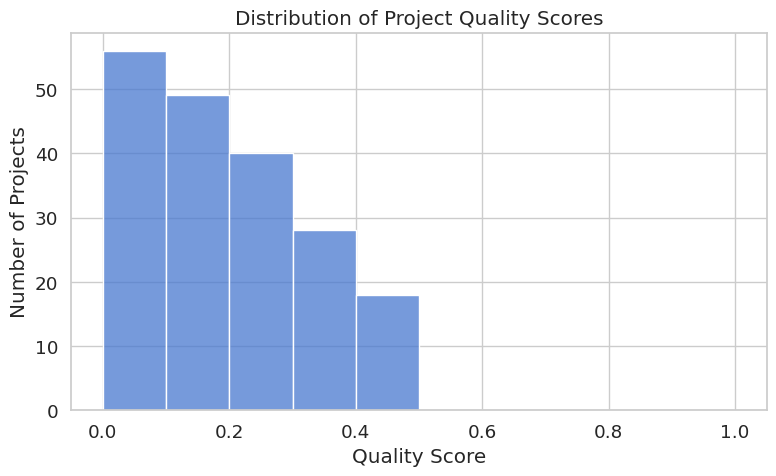

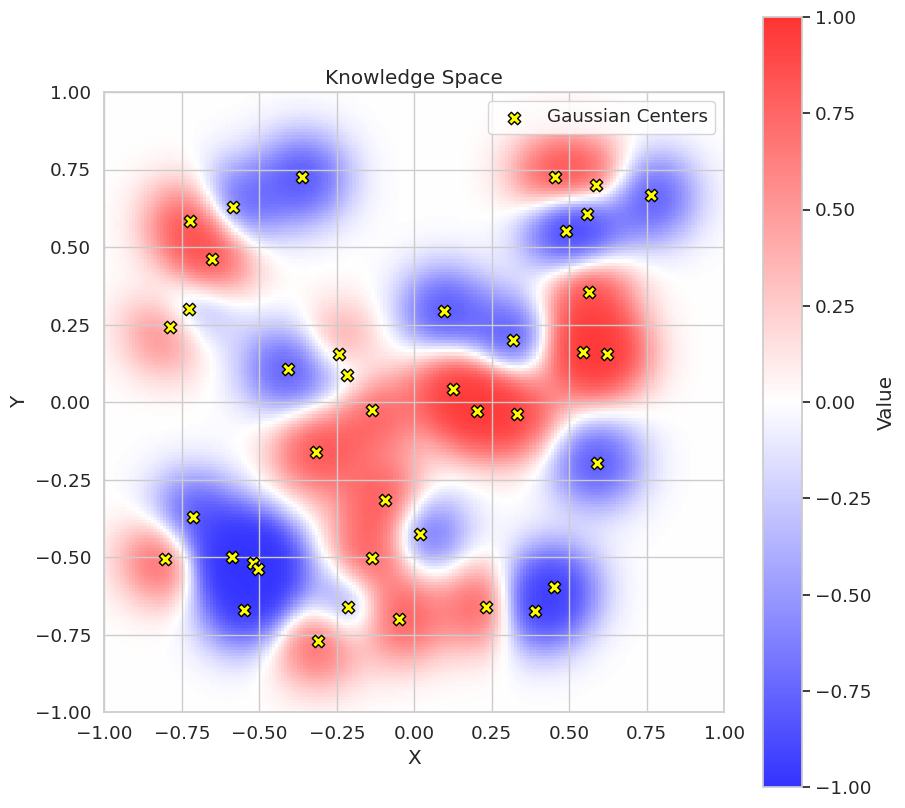

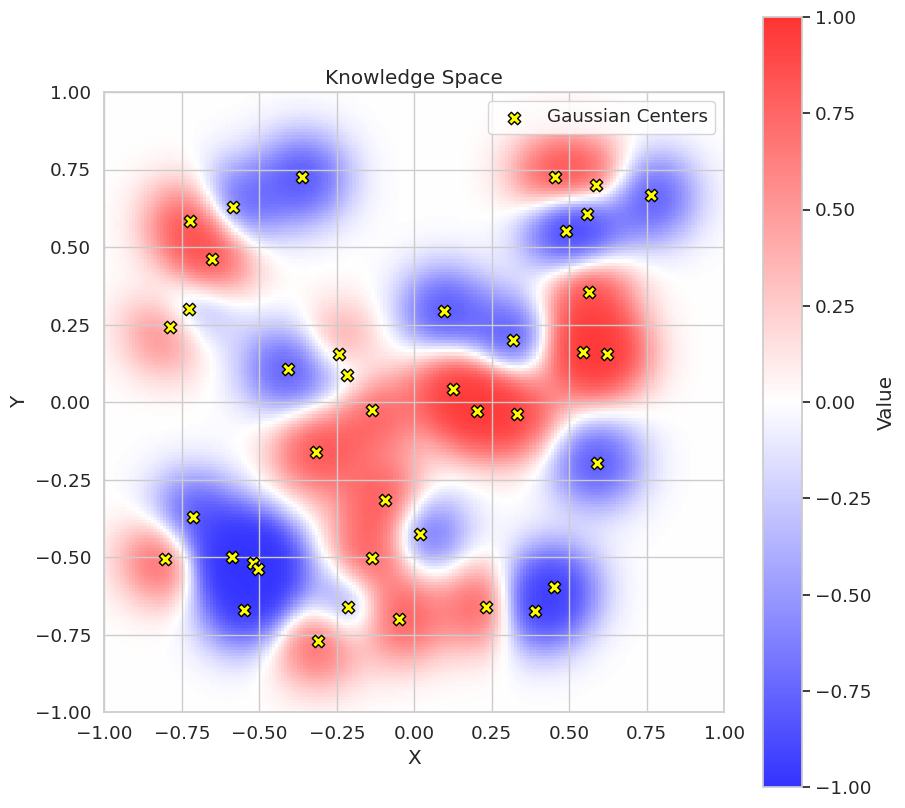

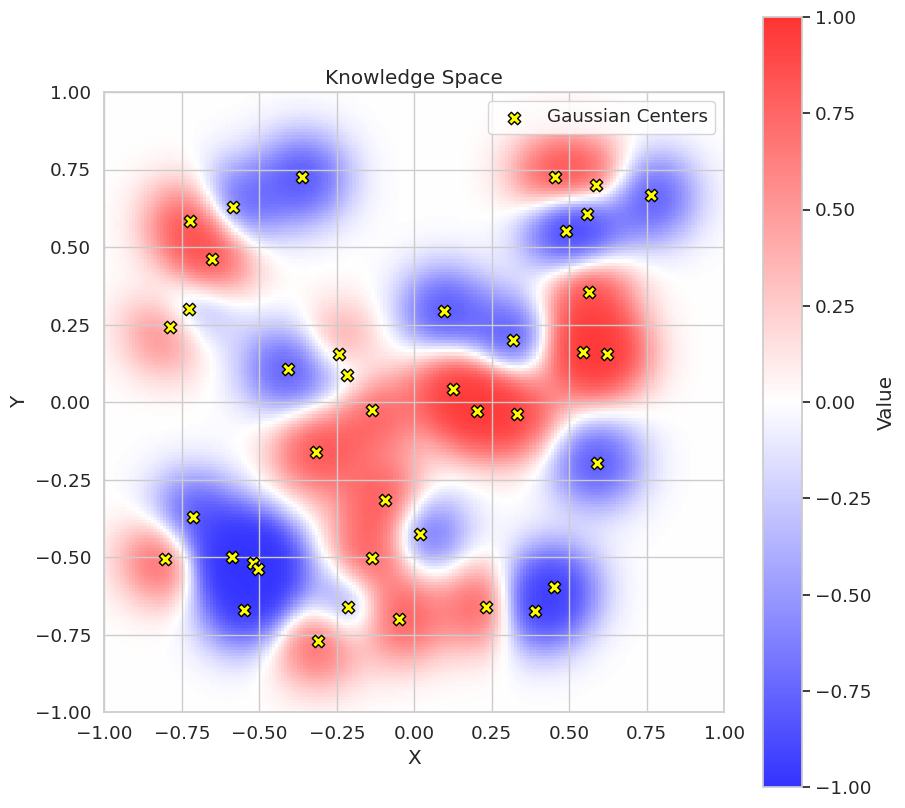

In [64]:
plot_histograms(balanced_multiply_projects, balanced_multiply_actions, f"log/balanced_adverse_{reward_type}_multiply_seed{seed}_area.pickle")